# LDA Analyses (PFC, mFC dataset)

Port of `code/LEC_lda_analyses.ipynb` to the mPFC dataset under
`mFC_data/data/`. Same three LDA pipelines as LEC:

- State separation on trial-bins ([lda_state_analysis_trialbins.py](lda_state_analysis_trialbins.py)) — including Pillai trace, LOTO / within-task / within-session-shuffle controls, and pseudotime-matched correlations.
- Goal-progress LDA ([lda_state_analysis_goalprogress.py](lda_state_analysis_goalprogress.py)).
- Reward × goal-progress LDA ([lda_reward_goalprogress.py](lda_reward_goalprogress.py)).

Only the data-loading cells are PFC-specific. The reward × goal-progress
section needs the pre-computed `Neurons_norm` field, so the PFC loader is
called with `compute_norm=True`.

## Method notes

**Trial extraction (state separation)**: each session's raw recording is z-scored across the concatenated timeline, then for every (trial, state) the mean population vector is taken across the state's raw time window. The result is a matrix $X \in \mathbb{R}^{N \times n_{neurons}}$ labelled by state $\in \{A,B,C,D\}$.

**Pillai's trace**: the sum $\sum_i \lambda_i / (1 + \lambda_i)$ over eigenvalues of $W^{-1}B$ where $W$ is the within-class scatter and $B$ is the between-class scatter. Bounded in $[0, n_{classes} - 1]$; equals 0 when classes are inseparable, approaches $n_{classes} - 1$ when perfectly separable.

**Roll-shuffle null**: each session's raw recording is circularly rolled by a random offset (at least one mean trial length) before re-running the full pipeline. This preserves autocorrelation structure while destroying state-activity alignment.

**Trial balancing** (new flag): if `balance_trials_per_task=True`, each session's trials are subsampled to `min(n_trials)` across sessions *before* trial-state extraction. The z-score still uses the full raw recording for stable normalisation. Prevents tasks with more trials from dominating the within-state scatter matrix. Applied identically to real and shuffled data.

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle
from importlib import reload

In [2]:
DATA_FOLDER = '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/data'
META = os.path.join(DATA_FOLDER, 'MetaData')

In [3]:
mouse_recdays = list(np.load(os.path.join(META, 'combined_ABCDonly_days.npy')).astype(str))
print(f'{len(mouse_recdays)} recdays in combined_ABCDonly_days.npy')
print('first 3:', mouse_recdays[:3])

25 recdays in combined_ABCDonly_days.npy
first 3: [np.str_('ab03_01092023_02092023'), np.str_('ab03_05092023_06092023'), np.str_('ab03_29082023_30082023')]


In [4]:
# compute_norm=True populates Neurons_norm + Locs_norm needed by the reward × goal-progress
# LDA section. The trialbins / goalprogress LDAs only need raw data and work either way.
# Memory note: this is ~4 GB across all 25 recdays. For a quick first pass, uncomment
# the next line to slice down.
# mouse_recdays = mouse_recdays[:5]

from glm_analysis_v2 import build_data_dic_from_pfc
data_dic = build_data_dic_from_pfc(DATA_FOLDER, mouse_recdays, compute_norm=True)
mouse_recdays = sorted(data_dic.keys())   # in case any were skipped
print(f'\n{len(mouse_recdays)} recdays loaded')

  ab03_01092023_02092023: 7 sessions
  ab03_05092023_06092023: 8 sessions
  ab03_29082023_30082023: 9 sessions
  ah03_12082021_13082021: 8 sessions
  ah03_18082021_19082021: 8 sessions
  ah04_01122021_02122021: 8 sessions
  ah04_05122021_06122021: 8 sessions
  ah04_07122021_08122021: 8 sessions
  ah04_09122021_10122021: 8 sessions
  ah04_14122021_16122021: 8 sessions
  ah07_01092023_02092023: 7 sessions
  ah07_27082023_28082023: 7 sessions
  ah07_29082023_30082023: 7 sessions
  me08_06092021_09092021: 8 sessions
  me08_10092021_11092021: 6 sessions
  me08_12092021_13092021: 7 sessions
  me10_09122021_10122021: 9 sessions
  me10_14122021_15122021: 6 sessions
  me10_17122021_19122021: 8 sessions
  me10_20122021_21122021: 6 sessions
  me11_01122021_02122021: 8 sessions
  me11_05122021_06122021: 9 sessions
  me11_07122021_08122021: 8 sessions
  me11_09122021_10122021: 9 sessions
  me11_12122021_13122021: 9 sessions

25 recdays loaded


In [5]:
# Build valid_sessions_dic: for each mouse_recday, keep one session per unique task structure
# Identical logic to the LEC notebook; works on PFC because num_trials and Task are present.
valid_sessions_dic = {}
for mouse_recday in mouse_recdays:
    valid_sessions = []
    tasks = []
    for session in list(data_dic[mouse_recday].keys()):
        if session == 'valid_sessions':
            continue
        if data_dic[mouse_recday][session]['num_trials'] < 5:
            print(f'{mouse_recday} session {session}: not enough trials, skipping')
            continue
        if 'defaultdict' in str(data_dic[mouse_recday][session]['Task']):
            print(f'{mouse_recday} session {session}: no task, skipping')
            continue
        if not any(np.array_equal(data_dic[mouse_recday][session]['Task'], candidate)
                   for candidate in tasks):
            tasks.append(data_dic[mouse_recday][session]['Task'])
            valid_sessions.append(session)
    print(f'{mouse_recday}: {valid_sessions}')
    valid_sessions_dic[mouse_recday] = valid_sessions

ab03_01092023_02092023: [0, 1, 2, 3, 4, 5]
ab03_05092023_06092023: [0, 1, 2, 4, 5, 6]
ab03_29082023_30082023: [0, 1, 2, 4, 6, 7]
ah03_12082021_13082021: [0, 1, 2, 4, 5, 6]
ah03_18082021_19082021: [0, 1, 2, 4, 5, 6]
ah04_01122021_02122021: [0, 1, 2, 4, 5, 6]
ah04_05122021_06122021: [0, 1, 2, 4, 5, 6]
ah04_07122021_08122021 session 2: not enough trials, skipping
ah04_07122021_08122021: [0, 1, 3, 4, 5, 6]
ah04_09122021_10122021: [0, 1, 2, 4, 5, 6]
ah04_14122021_16122021: [0, 1, 2, 4, 5, 6]
ah07_01092023_02092023: [0, 1, 2, 3, 4, 5]
ah07_27082023_28082023: [0, 1, 2, 4, 5, 6]
ah07_29082023_30082023 session 3: not enough trials, skipping
ah07_29082023_30082023: [0, 1, 2, 4, 5, 6]
me08_06092021_09092021 session 2: not enough trials, skipping
me08_06092021_09092021: [0, 1, 3, 4, 5, 6]
me08_10092021_11092021: [0, 1, 2, 4, 5]
me08_12092021_13092021: [0, 1, 3, 4, 5, 6]
me10_09122021_10122021: [0, 1, 2, 4, 6, 7]
me10_14122021_15122021: [0, 1, 2, 4]
me10_17122021_19122021: [0, 1, 2, 4, 5, 6]
me10_2

## State separation LDA (trial-bins)


Trial-bin LDA analysis: ab03_01092023_02092023
Sessions: [0, 1, 2, 3, 4, 5]
Task is (8, 3, 6, 4)
Task is (7, 2, 8, 9)
Task is (8, 4, 3, 5)
Task is (9, 5, 2, 8)
Task is (4, 9, 3, 6)
Task is (9, 7, 8, 5)
ab03_01092023_02092023: 6 sessions, 63 neurons
  Session 0 (index 0): 28 trials, T=46527 samples
  Session 1 (index 1): 28 trials, T=47157 samples
  Session 2 (index 2): 32 trials, T=48597 samples
  Session 3 (index 3): 39 trials, T=47648 samples
  Session 4 (index 4): 27 trials, T=47725 samples
  Session 5 (index 5): 29 trials, T=47054 samples
(array([0, 1, 2, 3, 4, 5]), array([112, 112, 128, 156, 108, 116]))
  Dataset: 732 samples (0 skipped) from 732 (trial, state) pairs
  PCA: keeping 14/63 PCs (76.4% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 732
Number of LDA components: 3
Explained variance ratio: [0.74731799 0.21665599 0.03602602]


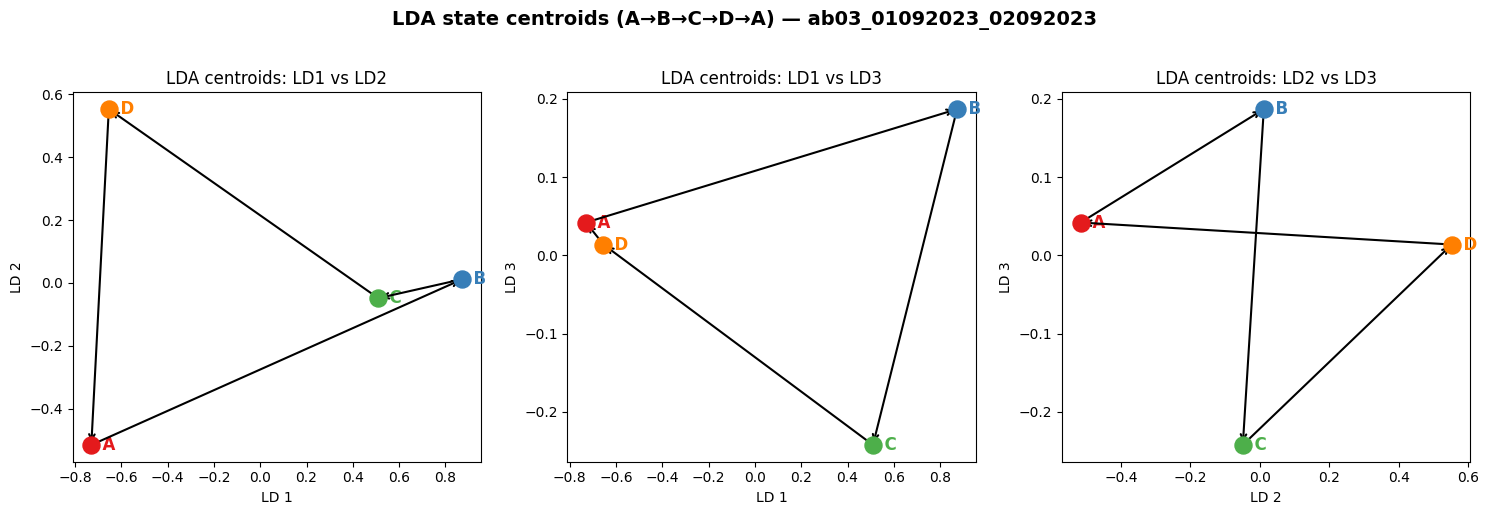

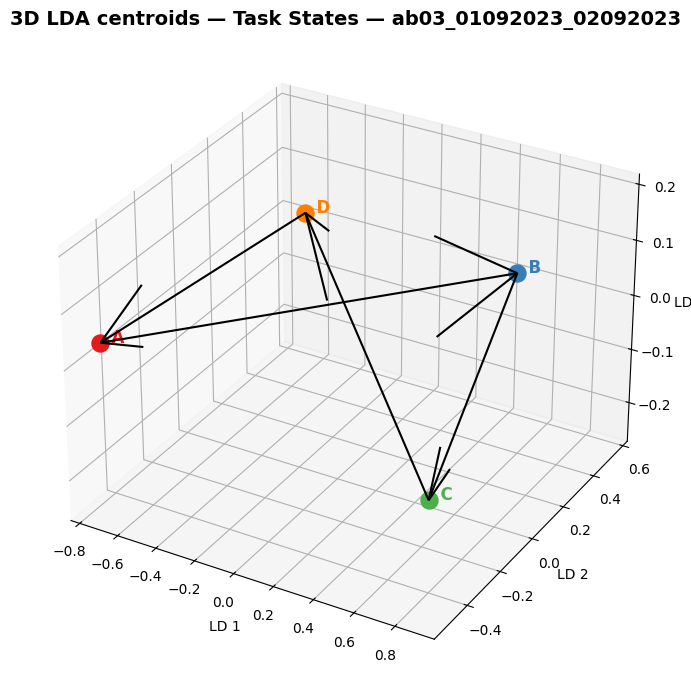

Working with sessions [0 1 2 3 4 5] (total 6)
Leave-one-session-out CV (6 sessions)
Real CV balanced accuracy: 0.255
Null: 0.249 ± 0.015
p = 0.3380


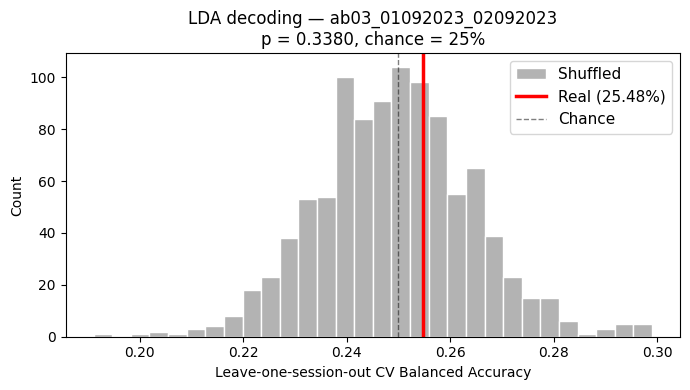

Computing null centroids with 1000 circular label rolls...


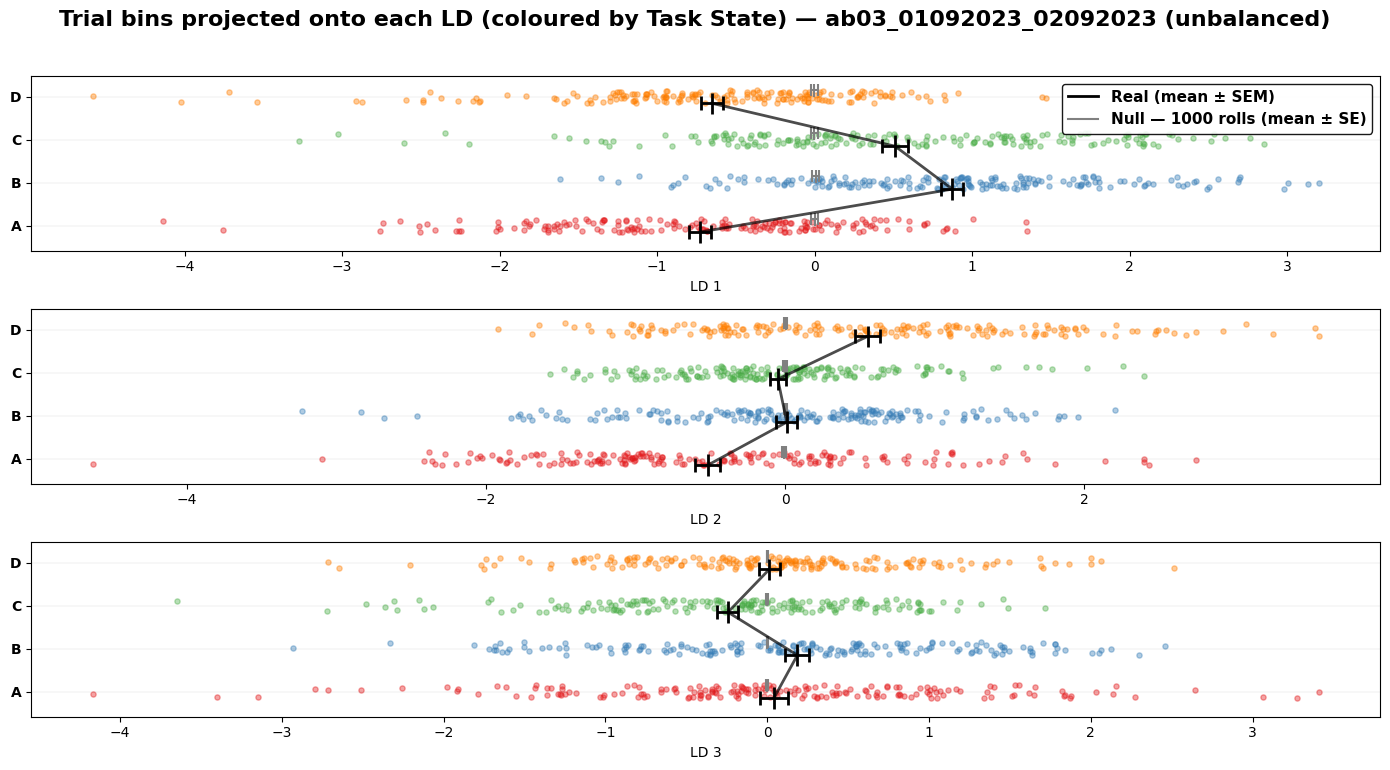

In [6]:
import lda_state_analysis_trialbins
import lda_state_separation
reload(lda_state_analysis_trialbins)
reload(lda_state_separation)
from lda_state_analysis_trialbins import run_trialbins_lda_analysis, plot_ld_projections
from lda_state_analysis_trialbins import EVENT_LABELS, EVENT_COLOURS

mouse_recday = mouse_recdays[0]

results_unbalanced = run_trialbins_lda_analysis(
    data_dic, mouse_recday,
    valid_sessions=valid_sessions_dic[mouse_recday],
    neuron_subset=None,
    balance_trials_per_task=False,
)
plot_ld_projections(results_unbalanced['X_state_ld'], results_unbalanced['y_state'],
                    EVENT_LABELS, EVENT_COLOURS, f'{mouse_recday} (unbalanced)')

## Trial-balanced state separation

Same analysis as above, but with `balance_trials_per_task=True` — each session's trials are subsampled to `min(n_trials)` across sessions before (trial, state) vector extraction. Sample count drops accordingly; class balance per state is preserved across tasks.


Trial-bin LDA analysis: ab03_01092023_02092023
Sessions: [0, 1, 2, 3, 4, 5]
Task is (8, 3, 6, 4)
Task is (7, 2, 8, 9)
Task is (8, 4, 3, 5)
Task is (9, 5, 2, 8)
Task is (4, 9, 3, 6)
Task is (9, 7, 8, 5)
ab03_01092023_02092023: 6 sessions, 63 neurons
  Balancing trials per task: keeping 27 per session (originally [28, 28, 32, 39, 27, 29])
  Session 0 (index 0): 27 trials, T=46527 samples
  Session 1 (index 1): 27 trials, T=47157 samples
  Session 2 (index 2): 27 trials, T=48597 samples
  Session 3 (index 3): 27 trials, T=47648 samples
  Session 4 (index 4): 27 trials, T=47725 samples
  Session 5 (index 5): 27 trials, T=47054 samples
(array([0, 1, 2, 3, 4, 5]), array([108, 108, 108, 108, 108, 108]))
  Dataset: 648 samples (0 skipped) from 648 (trial, state) pairs
  PCA: keeping 14/63 PCs (76.3% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 648
Number of LDA components: 3
Explained variance ratio: [0.74088878 0.19780318 0.06130804]


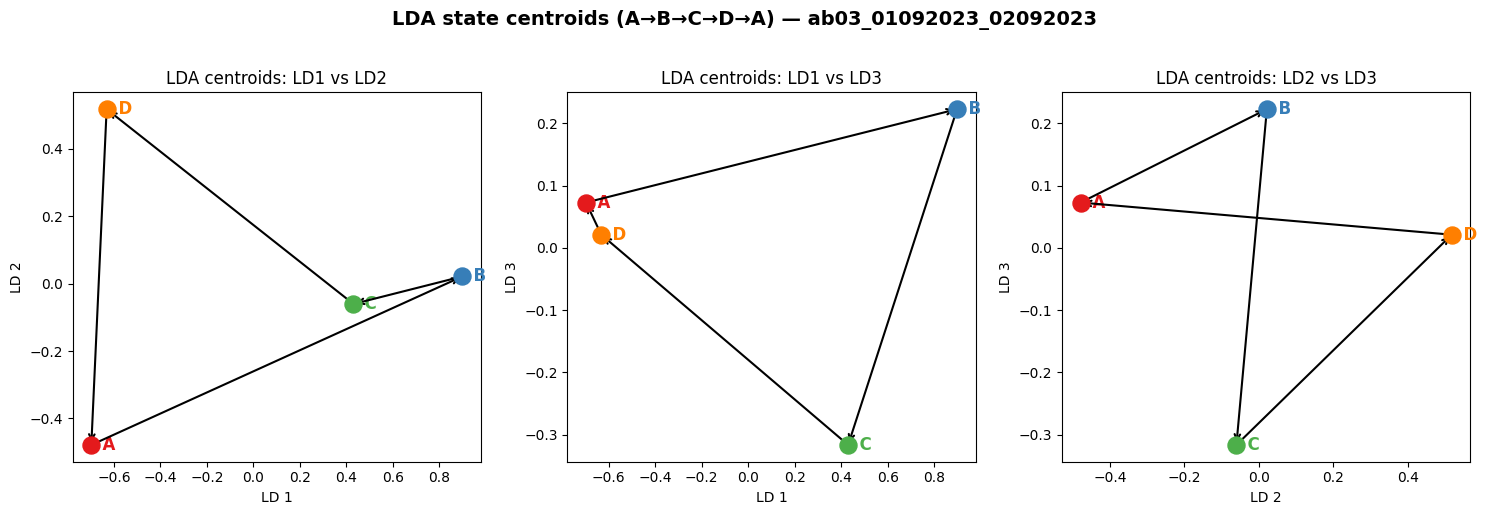

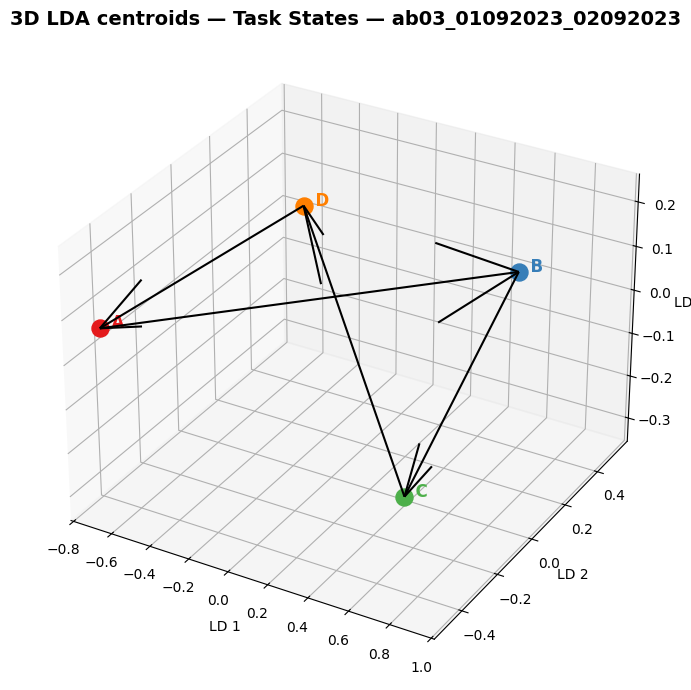

Working with sessions [0 1 2 3 4 5] (total 6)
Leave-one-session-out CV (6 sessions)
Real CV balanced accuracy: 0.264
Null: 0.250 ± 0.015
p = 0.1740


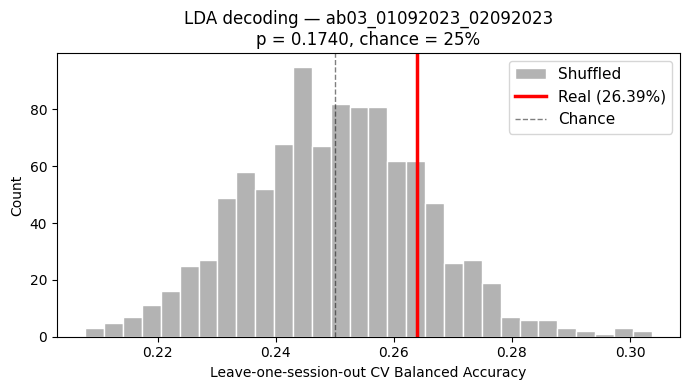

Computing null centroids with 1000 circular label rolls...


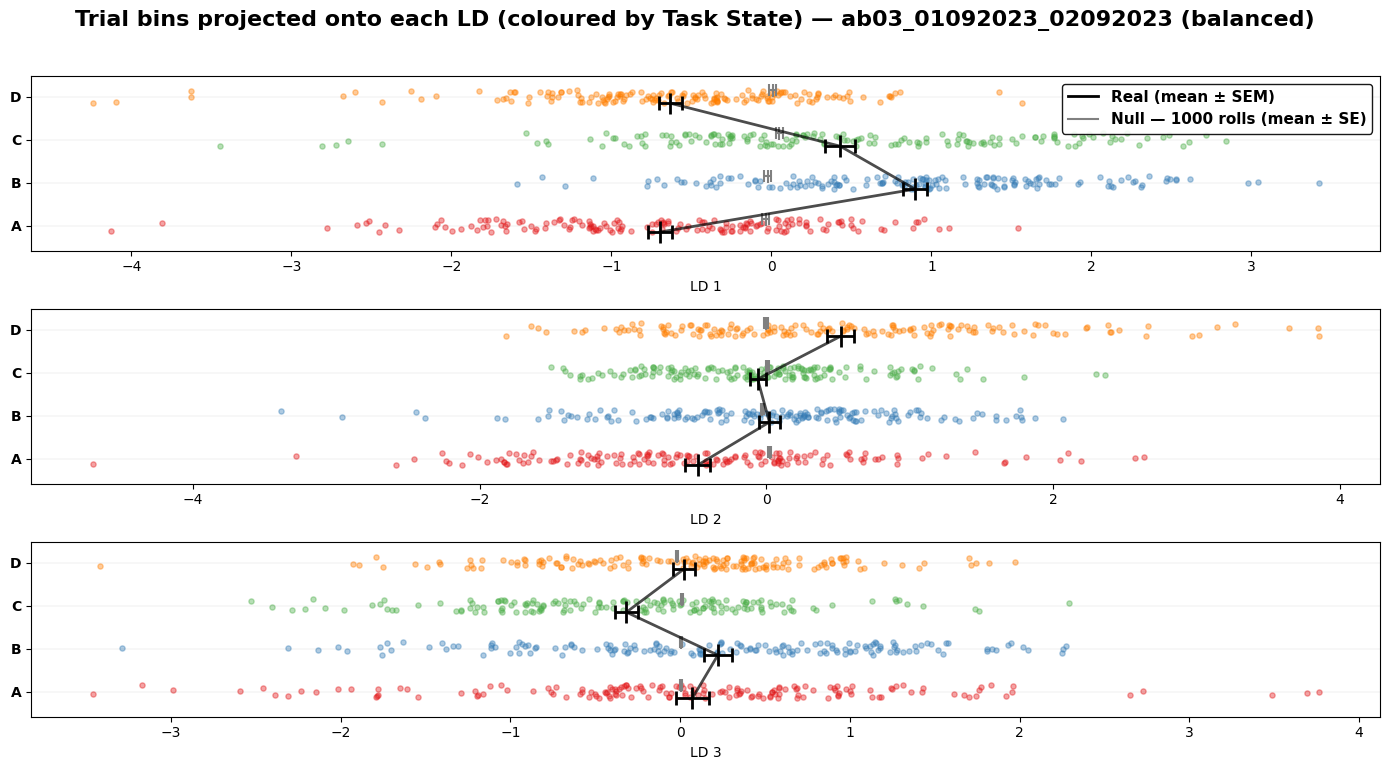

Unbalanced samples: 732
Balanced samples:   648
Unbalanced LOGO CV acc: 0.255 (p=0.3380)
Balanced LOGO CV acc:   0.264 (p=0.1740)


In [7]:
results_balanced = run_trialbins_lda_analysis(
    data_dic, mouse_recday,
    valid_sessions=valid_sessions_dic[mouse_recday],
    neuron_subset=None,
    balance_trials_per_task=True,
    balance_rng_seed=42,
)
plot_ld_projections(results_balanced['X_state_ld'], results_balanced['y_state'],
                    EVENT_LABELS, EVENT_COLOURS, f'{mouse_recday} (balanced)')

print(f"Unbalanced samples: {results_unbalanced['X'].shape[0]}")
print(f"Balanced samples:   {results_balanced['X'].shape[0]}")
print(f"Unbalanced LOGO CV acc: {results_unbalanced['real_acc']:.3f} (p={results_unbalanced['p_value']:.4f})")
print(f"Balanced LOGO CV acc:   {results_balanced['real_acc']:.3f} (p={results_balanced['p_value']:.4f})")

## Pillai-trace separability (trial-balanced)

Fits the same 4-class LDA but reports Pillai's trace and the per-LD eigenvalues, with a roll-shuffle null on the raw recordings. Trial balancing is on by default here.

ab03_01092023_02092023: 6 sessions, 63 neurons
  Balancing trials per task: keeping 27 per session (originally [28, 28, 32, 39, 27, 29])
  Real Pillai = 0.4703 | eigenvalues: [0.472 0.126 0.039]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


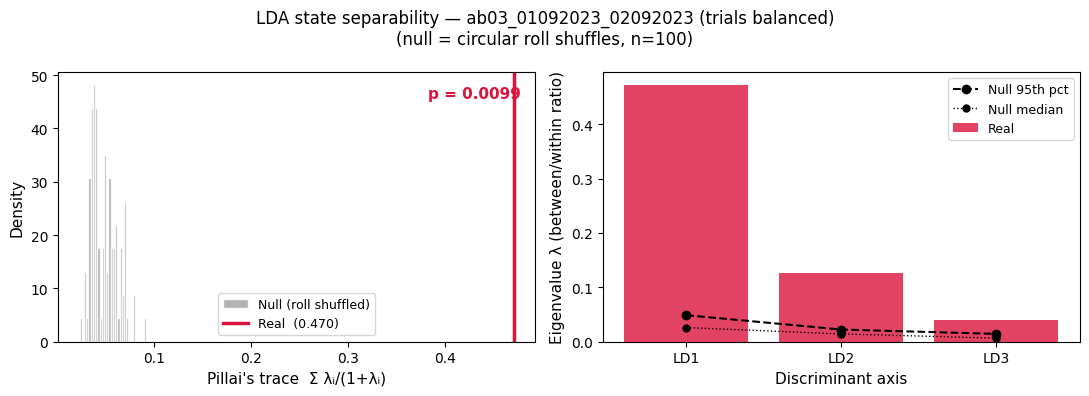

Pillai=0.4703, p=0.0099
Eigenvalues: [0.472 0.126 0.039]
ab03_05092023_06092023: 6 sessions, 64 neurons
  Balancing trials per task: keeping 11 per session (originally [29, 18, 13, 28, 20, 11])
  Real Pillai = 0.2069 | eigenvalues: [0.11  0.098 0.019]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


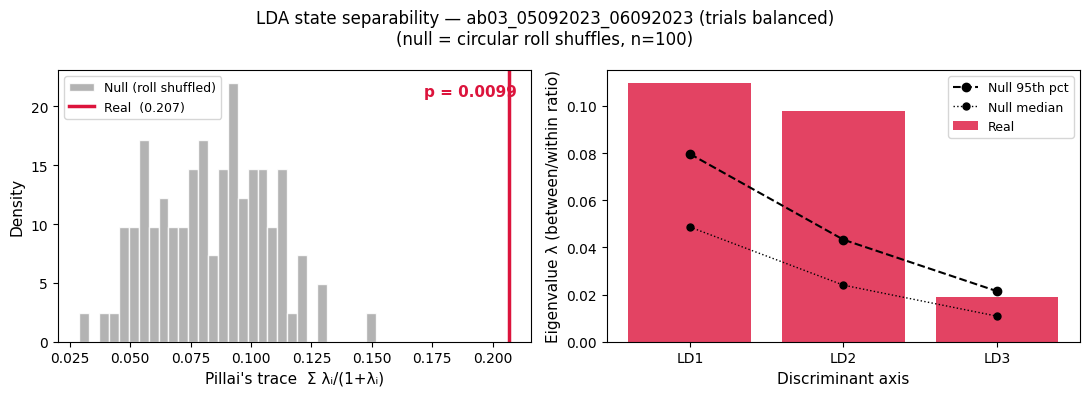

Pillai=0.2069, p=0.0099
Eigenvalues: [0.11  0.098 0.019]
ab03_29082023_30082023: 6 sessions, 70 neurons
  Balancing trials per task: keeping 13 per session (originally [27, 34, 24, 13, 19, 22])
  Real Pillai = 0.3542 | eigenvalues: [0.311 0.105 0.022]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


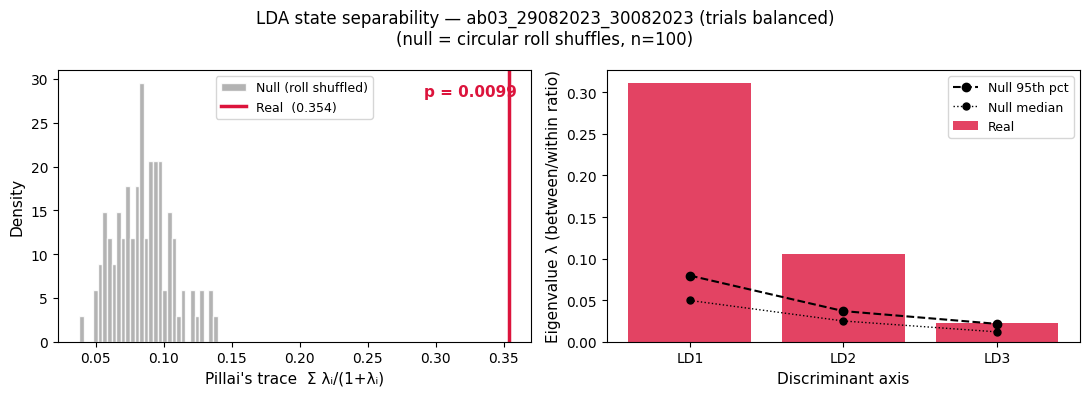

Pillai=0.3542, p=0.0099
Eigenvalues: [0.311 0.105 0.022]
ah03_12082021_13082021: 6 sessions, 16 neurons
  Balancing trials per task: keeping 23 per session (originally [31, 36, 41, 38, 46, 23])
  Real Pillai = 0.0233 | eigenvalues: [0.022 0.001 0.001]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0297  (n_valid_shuffles = 100)


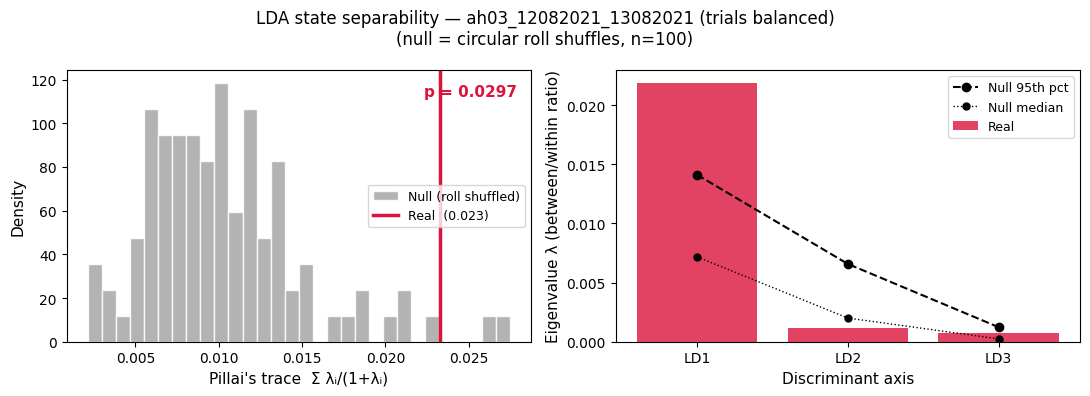

Pillai=0.0233, p=0.0297
Eigenvalues: [0.022 0.001 0.001]
ah03_18082021_19082021: 6 sessions, 15 neurons
  Balancing trials per task: keeping 28 per session (originally [31, 49, 52, 40, 28, 40])
  Real Pillai = 0.0300 | eigenvalues: [0.017 0.012 0.002]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


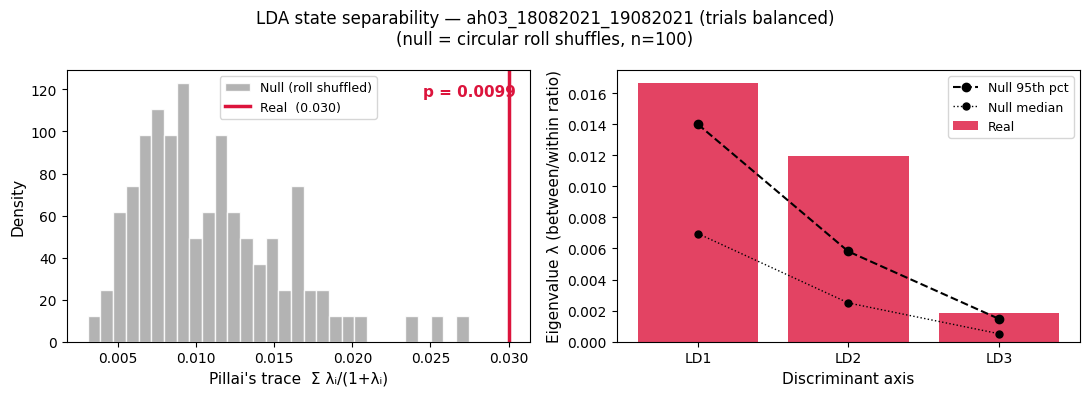

Pillai=0.0300, p=0.0099
Eigenvalues: [0.017 0.012 0.002]
ah04_01122021_02122021: 6 sessions, 117 neurons
  Balancing trials per task: keeping 19 per session (originally [19, 31, 31, 21, 31, 35])
  Real Pillai = 0.4574 | eigenvalues: [0.285 0.173 0.096]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


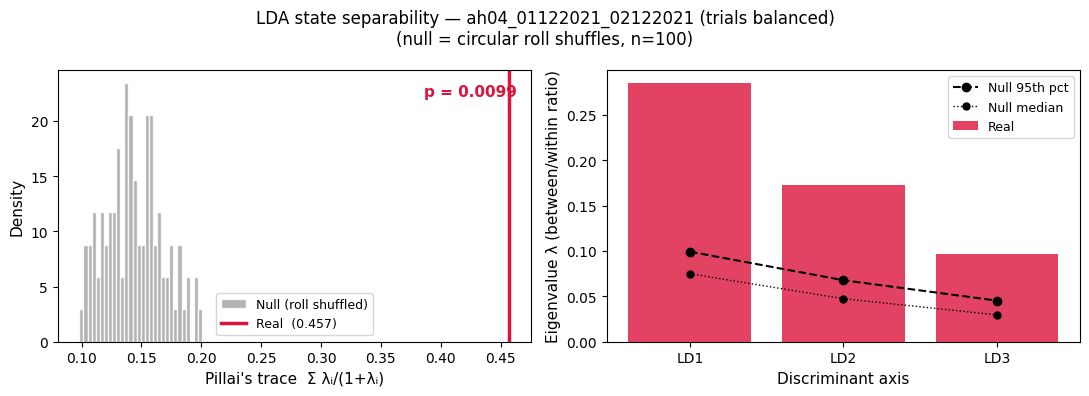

Pillai=0.4574, p=0.0099
Eigenvalues: [0.285 0.173 0.096]
ah04_05122021_06122021: 6 sessions, 114 neurons
  Balancing trials per task: keeping 14 per session (originally [41, 27, 28, 39, 14, 33])
  Real Pillai = 0.5190 | eigenvalues: [0.495 0.129 0.079]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


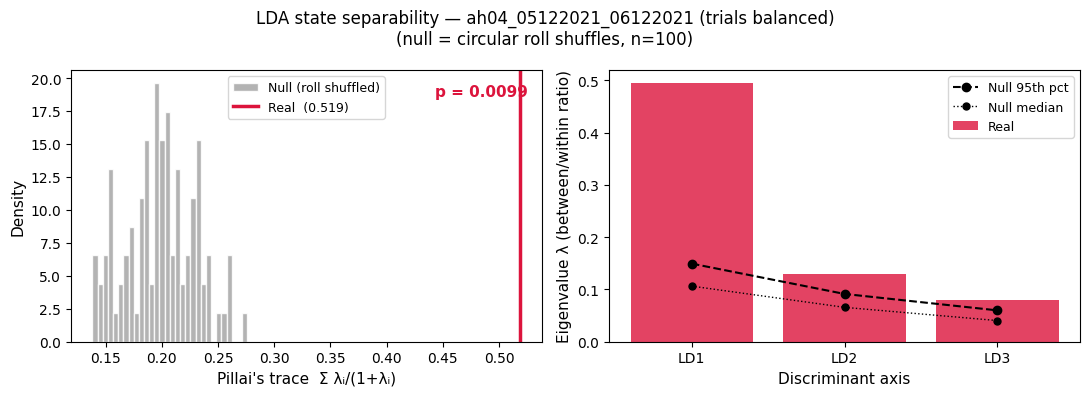

Pillai=0.5190, p=0.0099
Eigenvalues: [0.495 0.129 0.079]
ah04_07122021_08122021: 6 sessions, 81 neurons
  Balancing trials per task: keeping 16 per session (originally [26, 34, 37, 34, 23, 16])
  Real Pillai = 0.2464 | eigenvalues: [0.14  0.076 0.057]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


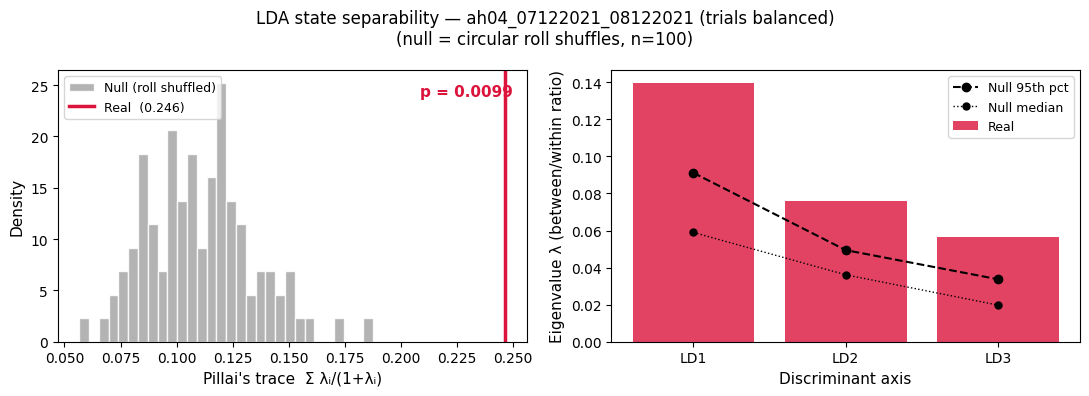

Pillai=0.2464, p=0.0099
Eigenvalues: [0.14  0.076 0.057]
ah04_09122021_10122021: 6 sessions, 99 neurons
  Balancing trials per task: keeping 31 per session (originally [31, 35, 36, 34, 37, 36])
  Real Pillai = 0.4116 | eigenvalues: [0.198 0.155 0.126]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


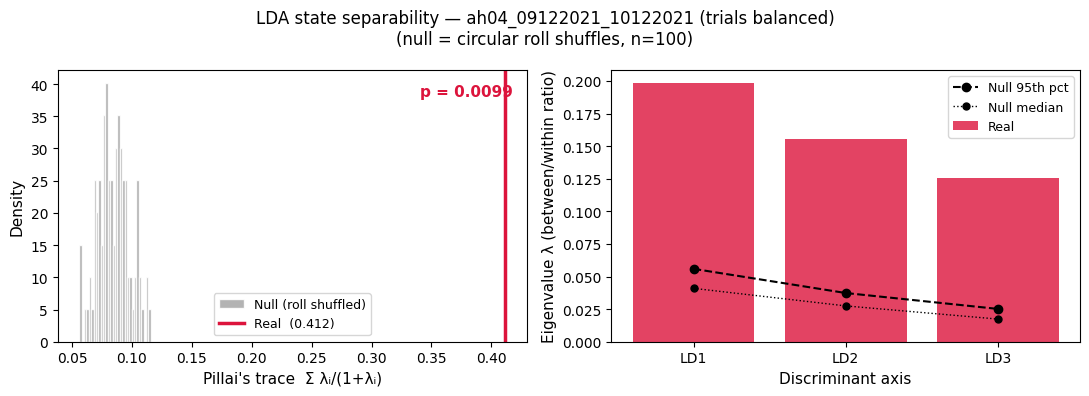

Pillai=0.4116, p=0.0099
Eigenvalues: [0.198 0.155 0.126]
ah04_14122021_16122021: 6 sessions, 70 neurons
  Balancing trials per task: keeping 29 per session (originally [29, 29, 37, 41, 33, 43])
  Real Pillai = 0.6245 | eigenvalues: [0.423 0.289 0.115]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


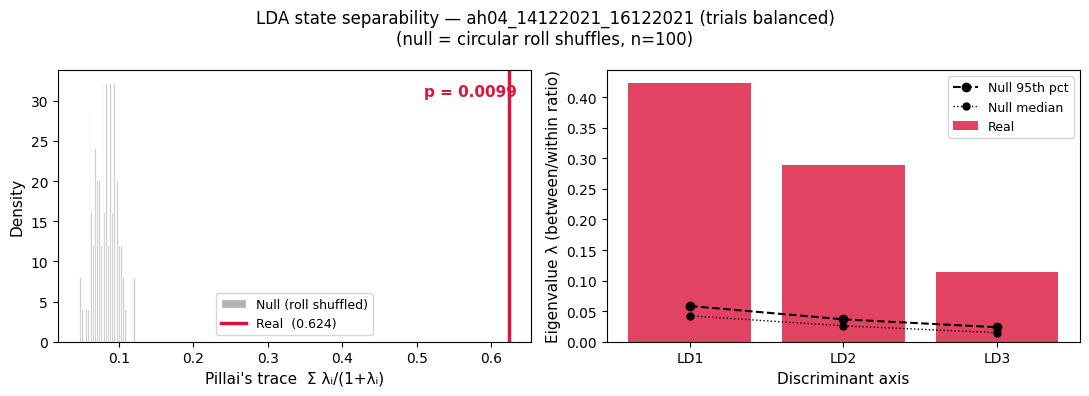

Pillai=0.6245, p=0.0099
Eigenvalues: [0.423 0.289 0.115]
ah07_01092023_02092023: 6 sessions, 97 neurons
  Balancing trials per task: keeping 13 per session (originally [31, 28, 13, 32, 27, 13])
  Real Pillai = 0.2949 | eigenvalues: [0.19  0.089 0.057]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


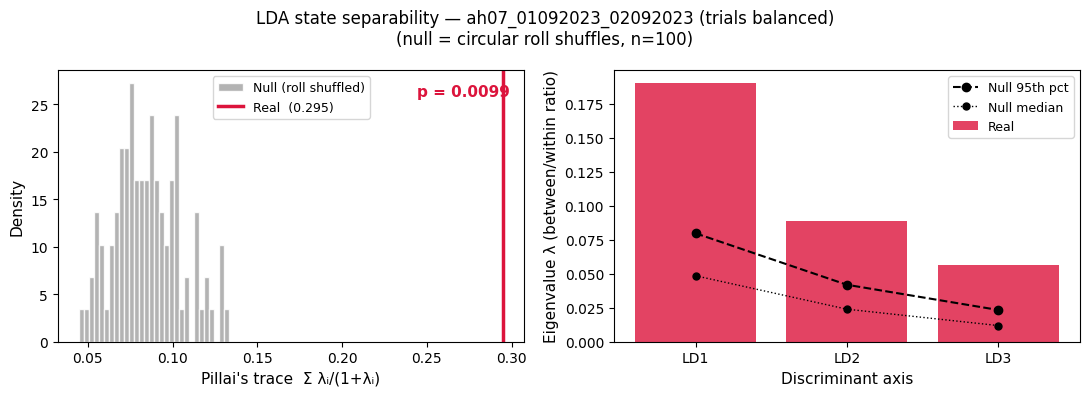

Pillai=0.2949, p=0.0099
Eigenvalues: [0.19  0.089 0.057]
ah07_27082023_28082023: 6 sessions, 80 neurons
  Balancing trials per task: keeping 10 per session (originally [14, 34, 34, 30, 35, 10])
  Real Pillai = 0.5274 | eigenvalues: [0.428 0.174 0.086]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


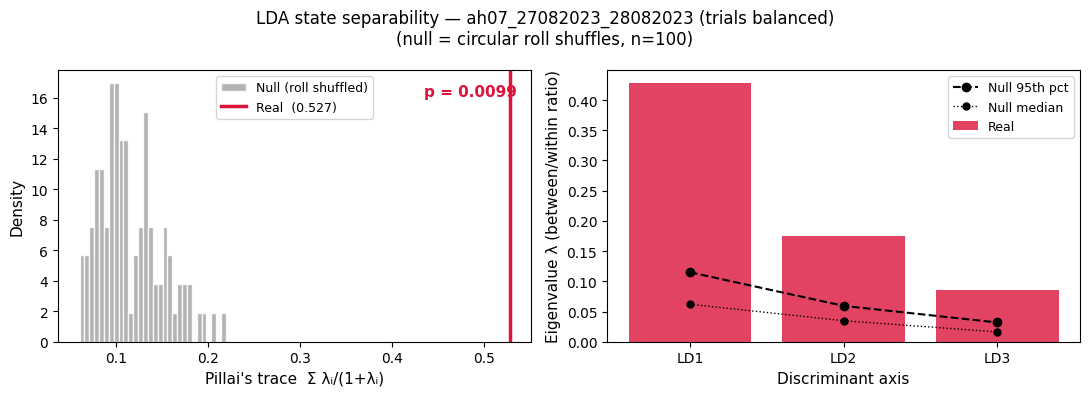

Pillai=0.5274, p=0.0099
Eigenvalues: [0.428 0.174 0.086]
ah07_29082023_30082023: 6 sessions, 72 neurons
  Balancing trials per task: keeping 12 per session (originally [23, 28, 27, 22, 12, 26])
  Real Pillai = 0.4234 | eigenvalues: [0.296 0.126 0.091]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


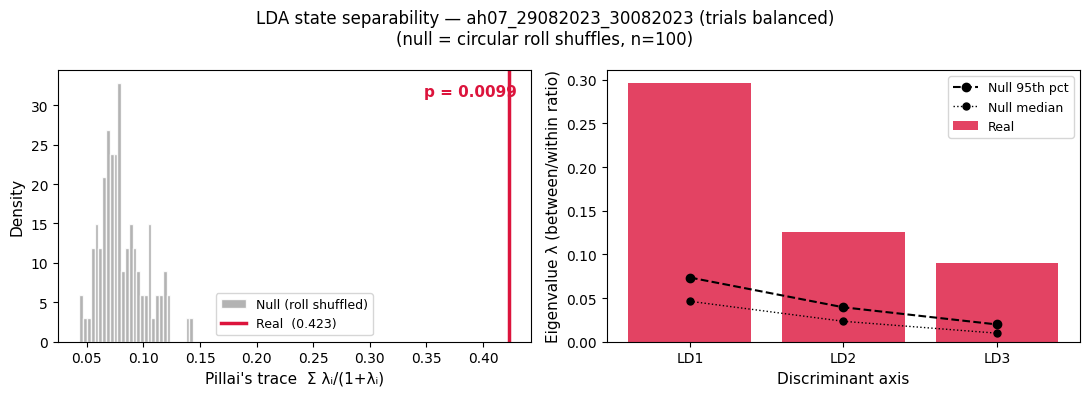

Pillai=0.4234, p=0.0099
Eigenvalues: [0.296 0.126 0.091]
me08_06092021_09092021: 6 sessions, 23 neurons
  Balancing trials per task: keeping 8 per session (originally [18, 11, 8, 16, 15, 15])
  Real Pillai = 0.1258 | eigenvalues: [0.105 0.026 0.005]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0693  (n_valid_shuffles = 100)


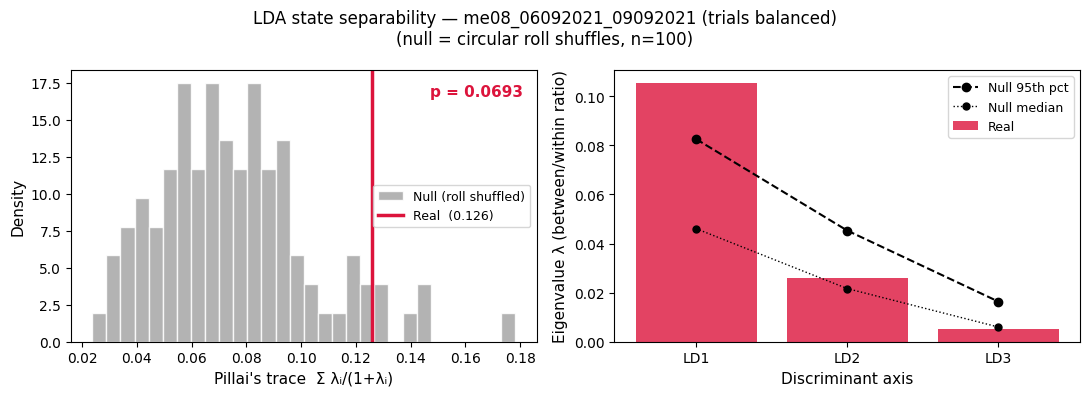

Pillai=0.1258, p=0.0693
Eigenvalues: [0.105 0.026 0.005]
me08_10092021_11092021: 5 sessions, 32 neurons
  Balancing trials per task: keeping 14 per session (originally [20, 16, 16, 14, 15])
  Real Pillai = 0.1778 | eigenvalues: [0.164 0.029 0.009]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


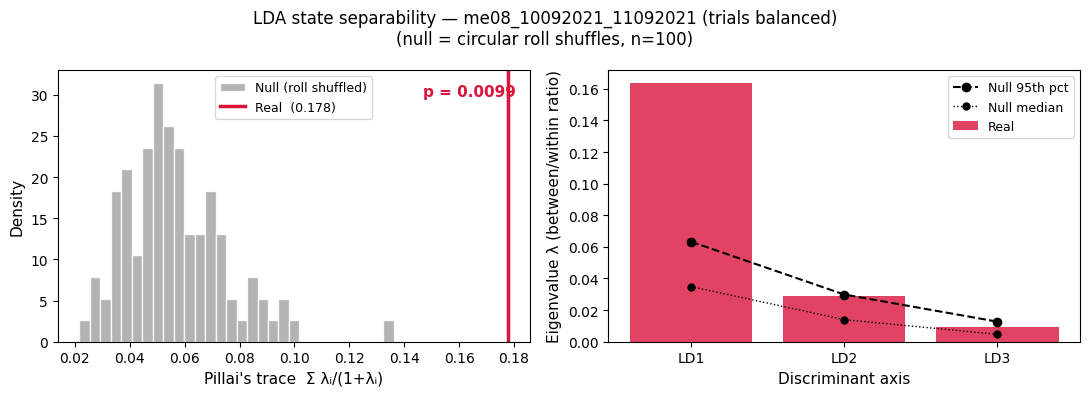

Pillai=0.1778, p=0.0099
Eigenvalues: [0.164 0.029 0.009]
me08_12092021_13092021: 6 sessions, 23 neurons
  Balancing trials per task: keeping 8 per session (originally [15, 15, 13, 13, 8, 12])
  Real Pillai = 0.0984 | eigenvalues: [0.054 0.046 0.003]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.1485  (n_valid_shuffles = 100)


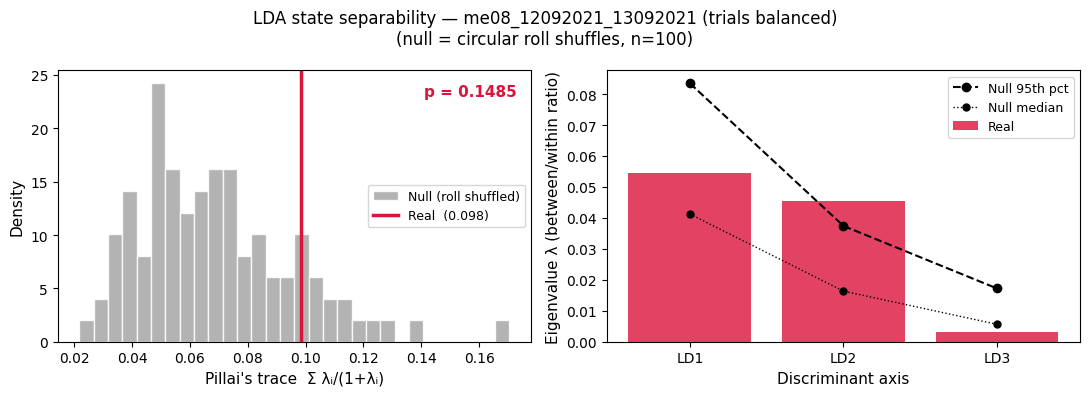

Pillai=0.0984, p=0.1485
Eigenvalues: [0.054 0.046 0.003]
me10_09122021_10122021: 6 sessions, 28 neurons
  Balancing trials per task: keeping 6 per session (originally [21, 21, 18, 6, 27, 24])
  Real Pillai = 0.1235 | eigenvalues: [0.074 0.037 0.02 ]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.3168  (n_valid_shuffles = 100)


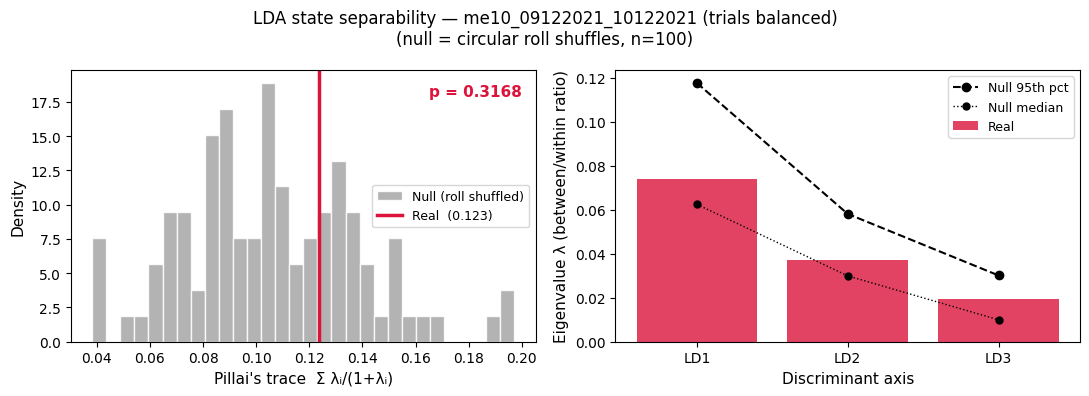

Pillai=0.1235, p=0.3168
Eigenvalues: [0.074 0.037 0.02 ]
me10_14122021_15122021: 4 sessions, 20 neurons
  Balancing trials per task: keeping 9 per session (originally [19, 12, 9, 26])
  Real Pillai = 0.1250 | eigenvalues: [0.071 0.036 0.024]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.1584  (n_valid_shuffles = 100)


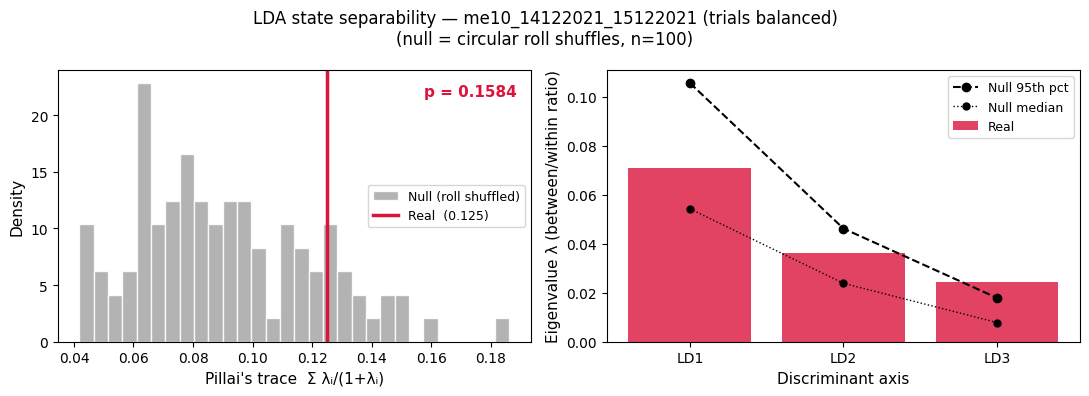

Pillai=0.1250, p=0.1584
Eigenvalues: [0.071 0.036 0.024]
me10_17122021_19122021: 6 sessions, 6 neurons
  Balancing trials per task: keeping 7 per session (originally [13, 15, 7, 16, 22, 30])
  Real Pillai = 0.0274 | eigenvalues: [0.022 0.006 0.   ]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.5347  (n_valid_shuffles = 100)


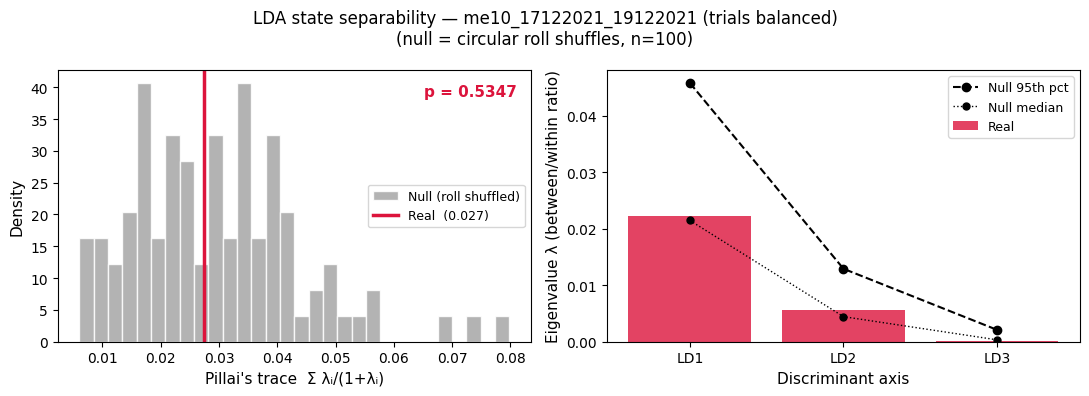

Pillai=0.0274, p=0.5347
Eigenvalues: [0.022 0.006 0.   ]
me10_20122021_21122021: 6 sessions, 1 neurons
  Balancing trials per task: keeping 9 per session (originally [9, 25, 32, 24, 23, 28])
  Real Pillai = 0.0015 | eigenvalues: [0.002]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.7723  (n_valid_shuffles = 100)


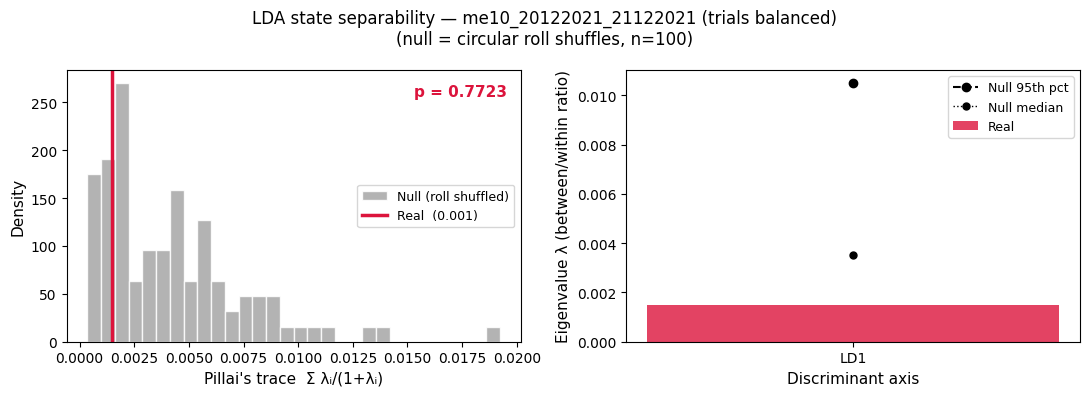

Pillai=0.0015, p=0.7723
Eigenvalues: [0.002]
me11_01122021_02122021: 7 sessions, 53 neurons
  Balancing trials per task: keeping 17 per session (originally [30, 24, 57, 31, 23, 43, 17])
  Real Pillai = 0.2679 | eigenvalues: [0.179 0.096 0.029]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


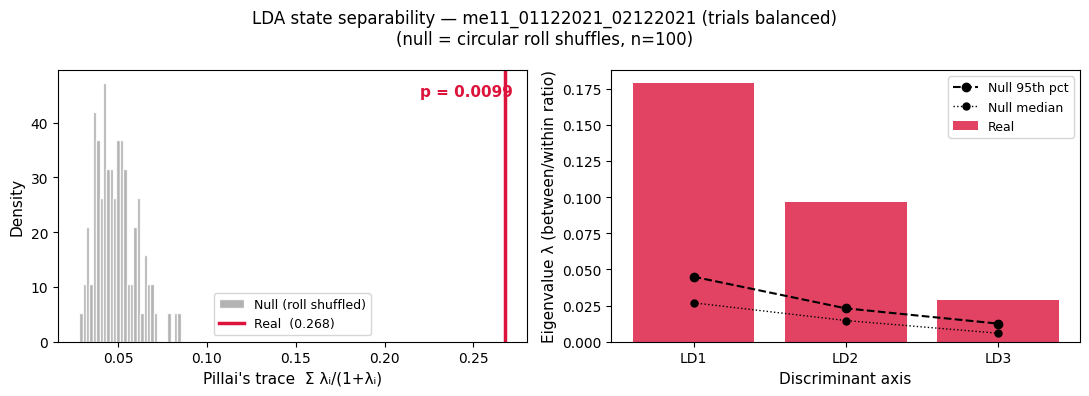

Pillai=0.2679, p=0.0099
Eigenvalues: [0.179 0.096 0.029]
me11_05122021_06122021: 7 sessions, 46 neurons
  Balancing trials per task: keeping 5 per session (originally [37, 38, 47, 50, 21, 5, 29])
  Real Pillai = 0.2525 | eigenvalues: [0.166 0.092 0.027]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0198  (n_valid_shuffles = 100)


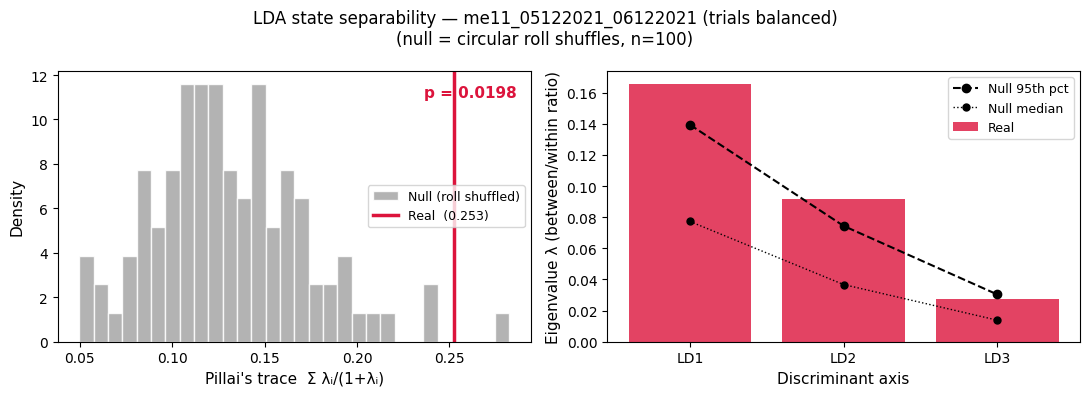

Pillai=0.2525, p=0.0198
Eigenvalues: [0.166 0.092 0.027]
me11_07122021_08122021: 6 sessions, 24 neurons
  Balancing trials per task: keeping 26 per session (originally [41, 26, 28, 28, 30, 31])
  Real Pillai = 0.1349 | eigenvalues: [0.096 0.036 0.013]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


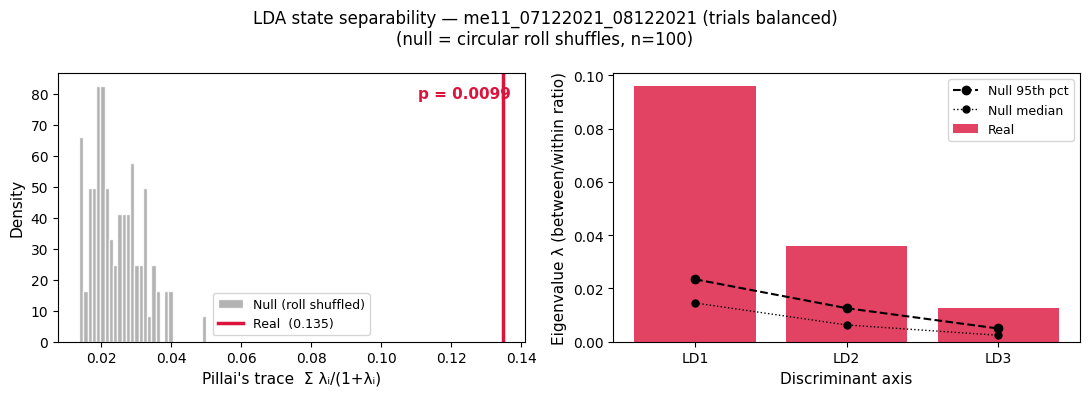

Pillai=0.1349, p=0.0099
Eigenvalues: [0.096 0.036 0.013]
me11_09122021_10122021: 6 sessions, 26 neurons
  Balancing trials per task: keeping 8 per session (originally [50, 16, 41, 8, 33, 30])
  Real Pillai = 0.4147 | eigenvalues: [0.312 0.141 0.057]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


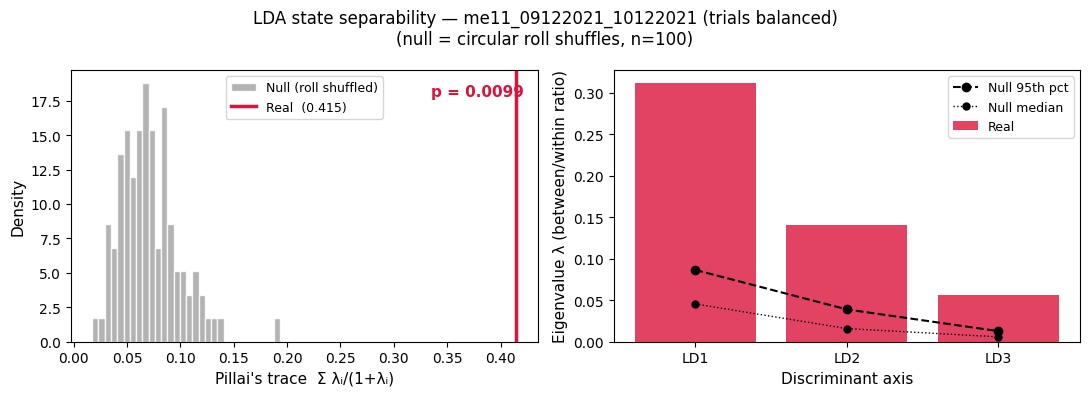

Pillai=0.4147, p=0.0099
Eigenvalues: [0.312 0.141 0.057]
me11_12122021_13122021: 5 sessions, 12 neurons
  Balancing trials per task: keeping 14 per session (originally [15, 15, 16, 14, 25])
  Real Pillai = 0.2552 | eigenvalues: [0.182 0.094 0.016]
  Shuffle 10/100 done
  Shuffle 20/100 done
  Shuffle 30/100 done
  Shuffle 40/100 done
  Shuffle 50/100 done
  Shuffle 60/100 done
  Shuffle 70/100 done
  Shuffle 80/100 done
  Shuffle 90/100 done
  Shuffle 100/100 done
  p = 0.0099  (n_valid_shuffles = 100)


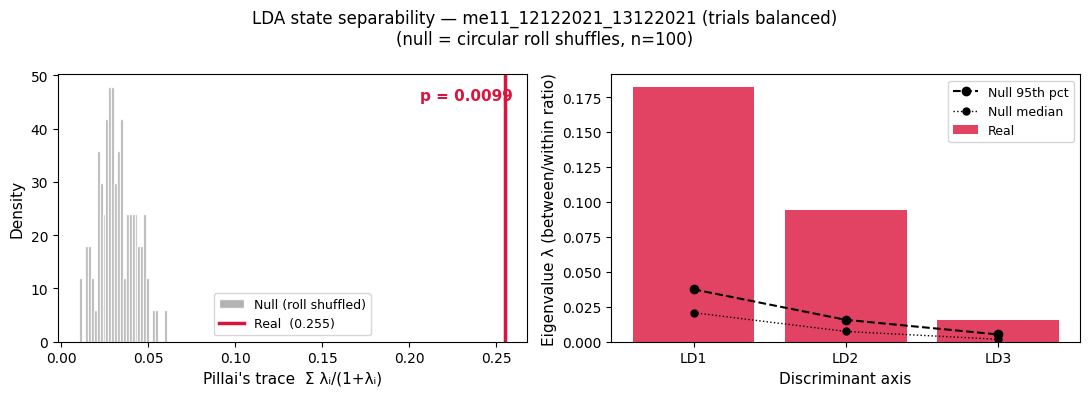

Pillai=0.2552, p=0.0099
Eigenvalues: [0.182 0.094 0.016]


In [8]:
from lda_state_analysis_trialbins import run_lda_eigenvalue_separation

for mouse_recday in mouse_recdays:
    sep = run_lda_eigenvalue_separation(
        data_dic, mouse_recday,
        valid_sessions=valid_sessions_dic[mouse_recday],
        neuron_subset=None,
        n_shuffles=100,
        balance_trials_per_task=True,
    )
    print(f"Pillai={sep['pillai']:.4f}, p={sep['p_value']:.4f}")
    print(f"Eigenvalues: {np.round(sep['eigenvalues'], 3)}")

### Controls for the Pillai-trace analysis

Three complementary tests of whether the large real-vs-null Pillai gap above reflects genuine **cross-task state tuning** vs an artefact of within-task similarity:

1. **T2 (within-task Pillai)** — fit LDA within each session separately and compare the average within-task Pillai to the across-task Pillai. If across-task ≫ within-task, pooling tasks adds signal. If similar, the across-task LDA is just averaging within-task structure.
2. **T1 (LOTO Pillai)** — fit LDA on N−1 sessions, project the held-out session's data through that fixed LDA, compute Pillai. Tests whether the LDA *direction* transfers across tasks.
3. **T3 (within-session shuffle null)** — stricter alternative null. Shuffles state labels within each session (preserving session structure, autocorrelation, and the actual extracted vectors) instead of rolling raw data. Conservative robustness check.

ab03_01092023_02092023: within-task Pillai over 6 sessions
  Session 0: Pillai=1.4114, p=0.0196
  Session 1: Pillai=1.6350, p=0.0196
  Session 2: Pillai=1.5635, p=0.0196
  Session 3: Pillai=2.2199, p=0.0196
  Session 4: Pillai=1.9784, p=0.0196
  Session 5: Pillai=2.2596, p=0.0196
ab03_01092023_02092023: mean within-task Pillai = 1.8446
ab03_05092023_06092023: within-task Pillai over 6 sessions
  Session 0: Pillai=1.3356, p=0.0196
  Session 1: Pillai=1.0292, p=0.0196
  Session 2: Pillai=1.2554, p=0.0196
  Session 4: Pillai=1.9970, p=0.0196
  Session 5: Pillai=1.5122, p=0.0196
  Session 6: Pillai=1.0968, p=0.0196
ab03_05092023_06092023: mean within-task Pillai = 1.3711
ab03_29082023_30082023: within-task Pillai over 6 sessions
  Session 0: Pillai=1.8979, p=0.0196
  Session 1: Pillai=1.8377, p=0.0196
  Session 2: Pillai=1.7465, p=0.0196
  Session 4: Pillai=1.4209, p=0.0196
  Session 6: Pillai=1.7147, p=0.0196
  Session 7: Pillai=1.7652, p=0.0196
ab03_29082023_30082023: mean within-task Pi

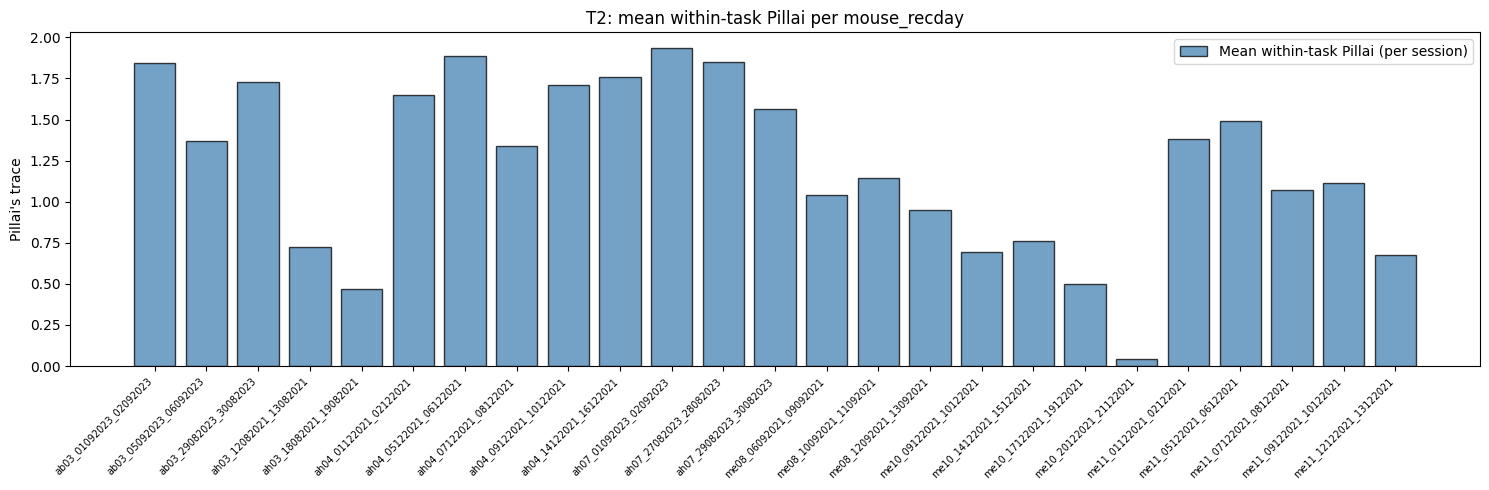

Mean within-task Pillai per mouse_recday:
  ab03_01092023_02092023: μ=1.8446  (per-session: [1.411, 1.635, 1.564, 2.22, 1.978, 2.26])
  ab03_05092023_06092023: μ=1.3711  (per-session: [1.336, 1.029, 1.255, 1.997, 1.512, 1.097])
  ab03_29082023_30082023: μ=1.7305  (per-session: [1.898, 1.838, 1.747, 1.421, 1.715, 1.765])
  ah03_12082021_13082021: μ=0.7229  (per-session: [0.404, 0.694, 0.649, 0.548, 1.512, 0.531])
  ah03_18082021_19082021: μ=0.4691  (per-session: [0.621, 0.327, 0.178, 0.612, 0.376, 0.7])
  ah04_01122021_02122021: μ=1.6489  (per-session: [2.155, 1.371, 2.259, 1.224, 1.277, 1.606])
  ah04_05122021_06122021: μ=1.8861  (per-session: [2.231, 1.507, 2.129, 2.341, 1.418, 1.69])
  ah04_07122021_08122021: μ=1.3382  (per-session: [1.657, 1.432, 0.34, 1.59, 1.653, 1.357])
  ah04_09122021_10122021: μ=1.7099  (per-session: [1.507, 1.455, 2.224, 1.443, 1.647, 1.983])
  ah04_14122021_16122021: μ=1.7592  (per-session: [1.628, 1.669, 1.977, 2.072, 1.522, 1.688])
  ah07_01092023_02092023:

In [9]:
# T2: within-task Pillai trace per session.
# Compare mean within-task Pillai to the across-task Pillai (`sep['pillai']` from cell above).

import lda_state_analysis_trialbins
reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import run_within_task_pillai

within_task_results = {}
across_task_pillais = {}  # mr -> across-task Pillai (one run of the original analysis)

for mr in mouse_recdays:
    try:
        within_task_results[mr] = run_within_task_pillai(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            n_shuffles=50,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')

# Per-mouse_recday: mean within-task Pillai vs across-task Pillai
recdays_sorted = sorted(within_task_results.keys())
fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(recdays_sorted)), 5))
x = np.arange(len(recdays_sorted))
within_means = [within_task_results[mr]['mean_within_task_pillai'] for mr in recdays_sorted]
ax.bar(x, within_means, color='steelblue', alpha=0.75, edgecolor='black',
       label='Mean within-task Pillai (per session)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(recdays_sorted, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("Pillai's trace")
ax.set_title('T2: mean within-task Pillai per mouse_recday')
ax.legend()
plt.tight_layout()
plt.show()

# Printed summary
print('Mean within-task Pillai per mouse_recday:')
for mr in recdays_sorted:
    r = within_task_results[mr]
    per_sess = r['per_session_pillais']
    valid = ~np.isnan(per_sess)
    print(f"  {mr}: \u03bc={r['mean_within_task_pillai']:.4f}  "
          f"(per-session: {np.round(per_sess[valid], 3).tolist()})")

Task is (8, 3, 6, 4)
Task is (7, 2, 8, 9)
Task is (8, 4, 3, 5)
Task is (9, 5, 2, 8)
Task is (4, 9, 3, 6)
Task is (9, 7, 8, 5)
ab03_01092023_02092023: 6 sessions, 63 neurons
  Session 0 (index 0): 28 trials, T=46527 samples
  Session 1 (index 1): 28 trials, T=47157 samples
  Session 2 (index 2): 32 trials, T=48597 samples
  Session 3 (index 3): 39 trials, T=47648 samples
  Session 4 (index 4): 27 trials, T=47725 samples
  Session 5 (index 5): 29 trials, T=47054 samples
(array([0, 1, 2, 3, 4, 5]), array([112, 112, 128, 156, 108, 116]))
  Dataset: 732 samples (0 skipped) from 732 (trial, state) pairs
ab03_01092023_02092023: LOTO over 6 sessions
  Fold 1/6 (held-out s=0): Pillai=1.5456, p=0.0196
  Fold 2/6 (held-out s=1): Pillai=1.6185, p=0.0196
  Fold 3/6 (held-out s=2): Pillai=1.3559, p=0.0196
  Fold 4/6 (held-out s=3): Pillai=2.0268, p=0.0196
  Fold 5/6 (held-out s=4): Pillai=2.0253, p=0.0196
  Fold 6/6 (held-out s=5): Pillai=2.0402, p=0.0196
ab03_01092023_02092023: mean LOTO Pillai = 1

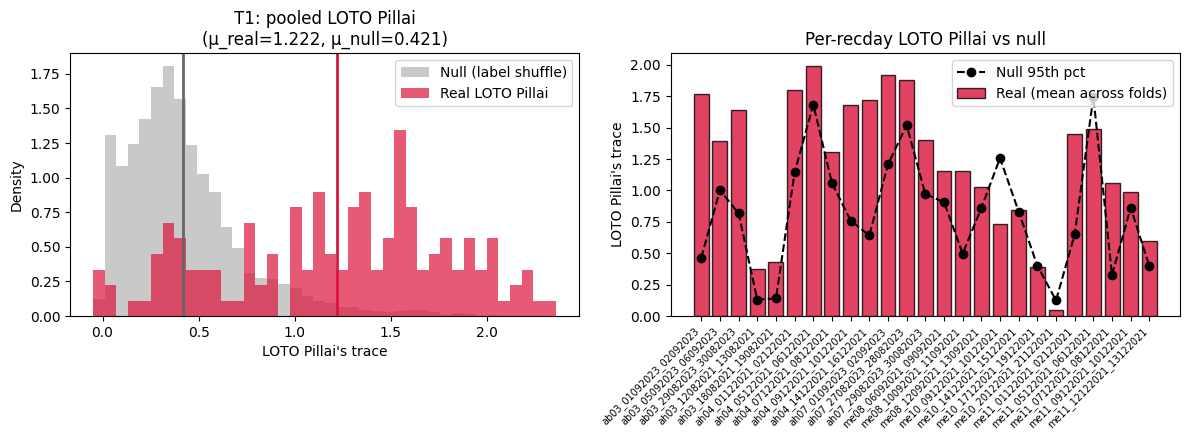

In [10]:
# T1: leave-one-task-out Pillai trace.
# For each held-out session, fit LDA on the rest; project held-out through it; compute Pillai.
# Tests whether the LDA direction generalises across tasks.

import lda_state_analysis_trialbins
reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import run_lda_eigenvalue_separation_loto

loto_results = {}
for mr in mouse_recdays:
    try:
        loto_results[mr] = run_lda_eigenvalue_separation_loto(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            n_shuffles=50,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')

# Pool LOTO Pillai across mouse_recdays
recdays_sorted = sorted(loto_results.keys())
all_real = np.concatenate([loto_results[mr]['loto_pillais'] for mr in recdays_sorted])
all_real = all_real[~np.isnan(all_real)]
all_null = np.concatenate([loto_results[mr]['null_loto_pillais'].ravel() for mr in recdays_sorted])
all_null = all_null[~np.isnan(all_null)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: pooled real vs null distribution
ax = axes[0]
bins = np.linspace(
    min(all_null.min(), all_real.min()) - 0.05,
    max(all_null.max(), all_real.max()) + 0.05, 41)
ax.hist(all_null, bins=bins, color='0.7', alpha=0.7, density=True, label='Null (label shuffle)')
ax.hist(all_real, bins=bins, color='crimson', alpha=0.7, density=True, label='Real LOTO Pillai')
ax.axvline(all_real.mean(), color='crimson', linewidth=2)
ax.axvline(all_null.mean(), color='0.4', linewidth=2)
ax.set_xlabel("LOTO Pillai's trace")
ax.set_ylabel('Density')
ax.set_title(f'T1: pooled LOTO Pillai\n(\u03bc_real={all_real.mean():.3f}, \u03bc_null={all_null.mean():.3f})')
ax.legend()

# Panel 2: per-mouse_recday mean LOTO Pillai vs null 95th pct
ax = axes[1]
x = np.arange(len(recdays_sorted))
mean_real = [np.nanmean(loto_results[mr]['loto_pillais']) for mr in recdays_sorted]
null_95 = [np.nanpercentile(loto_results[mr]['null_loto_pillais'], 95) for mr in recdays_sorted]
ax.bar(x, mean_real, color='crimson', alpha=0.8, edgecolor='black', label='Real (mean across folds)')
ax.plot(x, null_95, 'ko--', label='Null 95th pct')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(recdays_sorted, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("LOTO Pillai's trace")
ax.set_title('Per-recday LOTO Pillai vs null')
ax.legend()
plt.tight_layout()
plt.show()

Task is (8, 3, 6, 4)
Task is (7, 2, 8, 9)
Task is (8, 4, 3, 5)
Task is (9, 5, 2, 8)
Task is (4, 9, 3, 6)
Task is (9, 7, 8, 5)
ab03_01092023_02092023: 6 sessions, 63 neurons
  Session 0 (index 0): 28 trials, T=46527 samples
  Session 1 (index 1): 28 trials, T=47157 samples
  Session 2 (index 2): 32 trials, T=48597 samples
  Session 3 (index 3): 39 trials, T=47648 samples
  Session 4 (index 4): 27 trials, T=47725 samples
  Session 5 (index 5): 29 trials, T=47054 samples
(array([0, 1, 2, 3, 4, 5]), array([112, 112, 128, 156, 108, 116]))
  Dataset: 732 samples (0 skipped) from 732 (trial, state) pairs
ab03_01092023_02092023: real Pillai = 0.4821  (within-session shuffle null)
  Shuffle 20/100 done
  Shuffle 40/100 done
  Shuffle 60/100 done
  Shuffle 80/100 done
  Shuffle 100/100 done
  p = 0.0099 (n_valid_shuffles = 100)
Task is (5, 6, 4, 8)
Task is (4, 7, 2, 3)
Task is (3, 6, 7, 9)
Task is (6, 9, 2, 1)
Task is (9, 5, 8, 7)
Task is (7, 1, 5, 3)
ab03_05092023_06092023: 6 sessions, 64 neuro

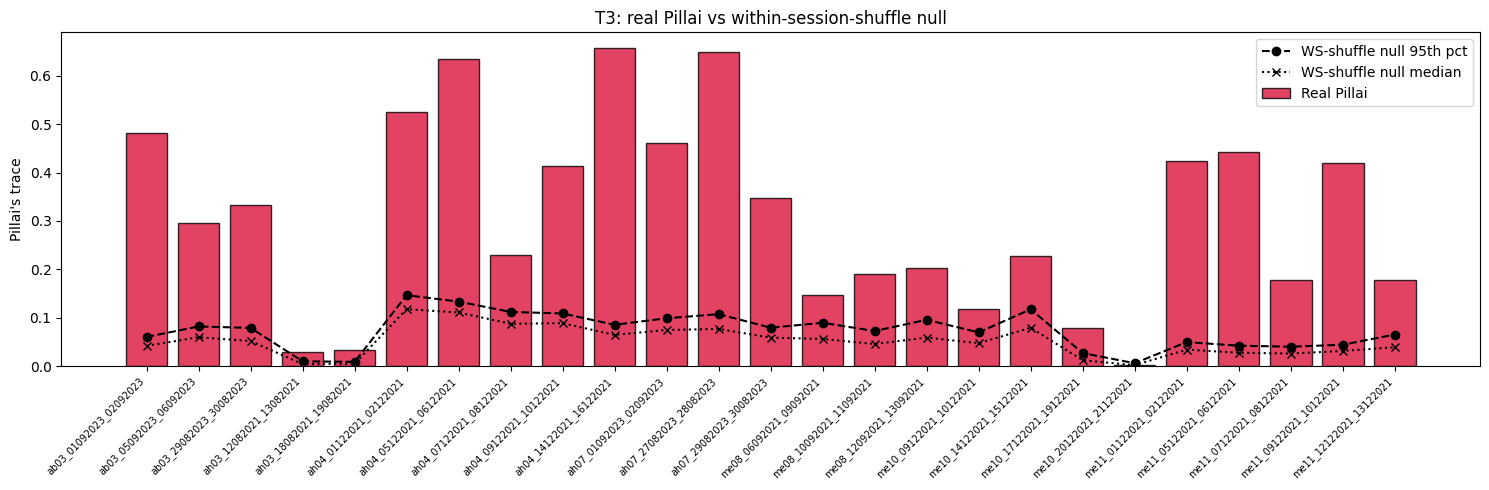

Per-recday p-values under within-session shuffle null:
  ab03_01092023_02092023: Pillai=0.4821, p=0.0099
  ab03_05092023_06092023: Pillai=0.2964, p=0.0099
  ab03_29082023_30082023: Pillai=0.3331, p=0.0099
  ah03_12082021_13082021: Pillai=0.0293, p=0.0099
  ah03_18082021_19082021: Pillai=0.0323, p=0.0099
  ah04_01122021_02122021: Pillai=0.5263, p=0.0099
  ah04_05122021_06122021: Pillai=0.6354, p=0.0099
  ah04_07122021_08122021: Pillai=0.2301, p=0.0099
  ah04_09122021_10122021: Pillai=0.4142, p=0.0099
  ah04_14122021_16122021: Pillai=0.6573, p=0.0099
  ah07_01092023_02092023: Pillai=0.4615, p=0.0099
  ah07_27082023_28082023: Pillai=0.6500, p=0.0099
  ah07_29082023_30082023: Pillai=0.3471, p=0.0099
  me08_06092021_09092021: Pillai=0.1459, p=0.0198
  me08_10092021_11092021: Pillai=0.1896, p=0.0099
  me08_12092021_13092021: Pillai=0.2018, p=0.0099
  me10_09122021_10122021: Pillai=0.1172, p=0.0099
  me10_14122021_15122021: Pillai=0.2280, p=0.0099
  me10_17122021_19122021: Pillai=0.0780, p=0.

In [11]:
# T3: within-session label-shuffle null.
# Stricter alternative null. Shuffles state labels within each session, preserving
# the actual extracted vectors and within-session structure. Compare to the
# existing roll-shuffle null.

import lda_state_analysis_trialbins
reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import run_within_session_shuffle_null

ws_null_results = {}
for mr in mouse_recdays:
    try:
        ws_null_results[mr] = run_within_session_shuffle_null(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            n_shuffles=100,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')

# Per-recday: real Pillai vs within-session-shuffle null 95th pct
recdays_sorted = sorted(ws_null_results.keys())
fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(recdays_sorted)), 5))
x = np.arange(len(recdays_sorted))
real_p = [ws_null_results[mr]['pillai'] for mr in recdays_sorted]
null_95 = [np.nanpercentile(ws_null_results[mr]['null_pillais'], 95) for mr in recdays_sorted]
null_50 = [np.nanpercentile(ws_null_results[mr]['null_pillais'], 50) for mr in recdays_sorted]
ax.bar(x, real_p, color='crimson', alpha=0.8, edgecolor='black', label='Real Pillai')
ax.plot(x, null_95, 'ko--', label='WS-shuffle null 95th pct')
ax.plot(x, null_50, 'kx:',  label='WS-shuffle null median')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(recdays_sorted, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("Pillai's trace")
ax.set_title('T3: real Pillai vs within-session-shuffle null')
ax.legend()
plt.tight_layout()
plt.show()

# Printed p-values per recday
print('Per-recday p-values under within-session shuffle null:')
for mr in recdays_sorted:
    r = ws_null_results[mr]
    print(f"  {mr}: Pillai={r['pillai']:.4f}, p={r['p_value']:.4f}")

## Pseudotime-matched state correlation (drift control)

For each pair of sessions and each *shared trial number*, correlate the population vector of state X in task 1 with that of state Y in task 2. Matching by trial number controls for slow drift in firing rates — paired trials sit at roughly the same point in the recording timeline, so drift affects both similarly. We then bucket the resulting correlations by whether the states match (within-state: X=Y) or differ (across-state: X≠Y).

**Prediction**: if neurons carry state information beyond drift, **within-state correlations exceed across-state correlations**. The two-sample t-test in the right panel quantifies the gap; the per-recday paired test reported at the bottom is more conservative (treats each recording as a single observation).

Uses `build_trialbins_dataset` + `compute_pseudotime_state_correlations` from `lda_state_analysis_trialbins.py`.

Task is (8, 3, 6, 4)
Task is (7, 2, 8, 9)
Task is (8, 4, 3, 5)
Task is (9, 5, 2, 8)
Task is (4, 9, 3, 6)
Task is (9, 7, 8, 5)
ab03_01092023_02092023: 6 sessions, 63 neurons
  Session 0 (index 0): 28 trials, T=46527 samples
  Session 1 (index 1): 28 trials, T=47157 samples
  Session 2 (index 2): 32 trials, T=48597 samples
  Session 3 (index 3): 39 trials, T=47648 samples
  Session 4 (index 4): 27 trials, T=47725 samples
  Session 5 (index 5): 29 trials, T=47054 samples
(array([0, 1, 2, 3, 4, 5]), array([112, 112, 128, 156, 108, 116]))
  Dataset: 732 samples (0 skipped) from 732 (trial, state) pairs
  ab03_01092023_02092023: within μ=-0.006 (n=1684)  across μ=-0.008 (n=5052)
Task is (5, 6, 4, 8)
Task is (4, 7, 2, 3)
Task is (3, 6, 7, 9)
Task is (6, 9, 2, 1)
Task is (9, 5, 8, 7)
Task is (7, 1, 5, 3)
ab03_05092023_06092023: 6 sessions, 64 neurons
  Session 0 (index 0): 29 trials, T=47677 samples
  Session 1 (index 1): 18 trials, T=44462 samples
  Session 2 (index 2): 13 trials, T=46532 sam

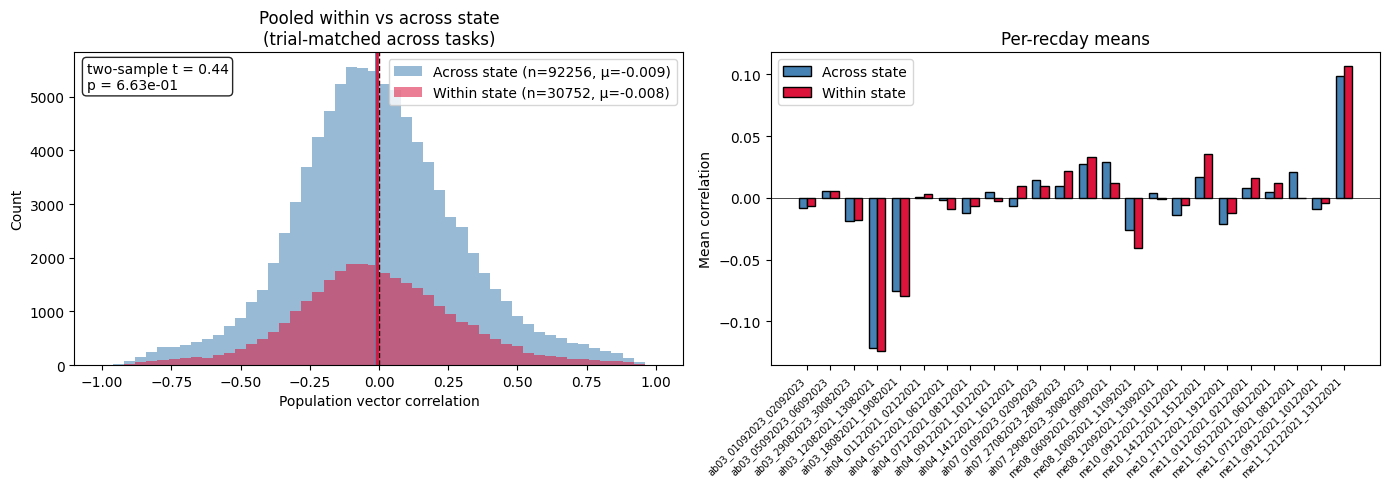


Per-recday paired test (within - across): mean Δ=0.0010, t=0.51, p=6.14e-01


In [12]:
# Pseudotime-matched state correlation across mouse_recdays.
# For each (session_pair, shared trial number, state_a, state_b): correlate the
# two population vectors. Within-state pairs (state_a == state_b) should exceed
# across-state pairs if state tuning isn't explained by global drift.

reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import (
    build_trialbins_dataset,
    compute_pseudotime_state_correlations,
    EVENT_LABELS,
)

pooled_within = []
pooled_across = []
per_recday = {}  # mouse_recday -> (mean_within, mean_across, n_within, n_across)
per_recday_arrays = {}  # mouse_recday -> (within_arr, across_arr) for downstream grouping

for mr in mouse_recdays:
    try:
        X, y_state, sess_id, trial_id, _, _ = build_trialbins_dataset(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            neuron_subset=None,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')
        continue

    within, across = compute_pseudotime_state_correlations(X, y_state, sess_id, trial_id)
    if not within or not across:
        print(f'  {mr}: no comparable pairs, skipped')
        continue

    w = np.array([d['corr'] for d in within])
    a = np.array([d['corr'] for d in across])
    pooled_within.append(w)
    pooled_across.append(a)
    per_recday[mr] = (w.mean(), a.mean(), len(w), len(a))
    per_recday_arrays[mr] = (w, a)
    print(f"  {mr}: within \u03bc={w.mean():.3f} (n={len(w)})  across \u03bc={a.mean():.3f} (n={len(a)})")

pooled_within = np.concatenate(pooled_within)
pooled_across = np.concatenate(pooled_across)

# --- Cross-mouse summary figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(-1, 1, 51)
ax.hist(pooled_across, bins=bins, color='steelblue', alpha=0.55,
        label=f'Across state (n={len(pooled_across)}, \u03bc={pooled_across.mean():.3f})')
ax.hist(pooled_within, bins=bins, color='crimson', alpha=0.55,
        label=f'Within state (n={len(pooled_within)}, \u03bc={pooled_within.mean():.3f})')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(pooled_across.mean(), color='steelblue', linewidth=2)
ax.axvline(pooled_within.mean(), color='crimson', linewidth=2)
t_stat, p_val = st.ttest_ind(pooled_within, pooled_across)
ax.text(0.02, 0.97, f'two-sample t = {t_stat:.2f}\np = {p_val:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax.set_xlabel('Population vector correlation')
ax.set_ylabel('Count')
ax.set_title('Pooled within vs across state\n(trial-matched across tasks)')
ax.legend(loc='upper right')

ax = axes[1]
recdays_sorted = sorted(per_recday.keys())
w_means = [per_recday[mr][0] for mr in recdays_sorted]
a_means = [per_recday[mr][1] for mr in recdays_sorted]
x = np.arange(len(recdays_sorted))
ax.bar(x - 0.18, a_means, width=0.36, color='steelblue', label='Across state', edgecolor='black')
ax.bar(x + 0.18, w_means, width=0.36, color='crimson', label='Within state', edgecolor='black')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(recdays_sorted, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Mean correlation')
ax.set_title('Per-recday means')
ax.legend()

plt.tight_layout()
plt.show()

# Paired test at the recday level (more conservative than pooling)
diffs = np.array(w_means) - np.array(a_means)
t_paired, p_paired = st.ttest_1samp(diffs, 0)
print(f"\nPer-recday paired test (within - across): "
      f"mean \u0394={diffs.mean():.4f}, t={t_paired:.2f}, p={p_paired:.2e}")

### Per-mouse breakdown

Aggregate within/across-state correlations by **mouse identity** (the first underscore-separated token of `mouse_recday`, e.g. `ah08`). Concatenates all of a mouse's recdays and produces (a) a histogram grid (one per mouse, overlaying within vs across) and (b) a bar chart of per-mouse means.

Per-mouse paired test (treats each mouse as one observation of `within − across` averaged across its recdays) is the most conservative inference at this granularity.

  ab03: 3 recdays, within μ=-0.007 (n=3728)  across μ=-0.008 (n=11184)
  ah03: 2 recdays, within μ=-0.100 (n=3908)  across μ=-0.097 (n=11724)
  ah04: 5 recdays, within μ=-0.001 (n=8252)  across μ=-0.003 (n=24756)
  ah07: 3 recdays, within μ=0.022 (n=3516)  across μ=0.017 (n=10548)
  me08: 3 recdays, within μ=-0.008 (n=1968)  across μ=0.004 (n=5904)
  me10: 3 recdays, within μ=-0.002 (n=1948)  across μ=-0.012 (n=5844)
  me11: 5 recdays, within μ=0.015 (n=7432)  across μ=0.015 (n=22296)


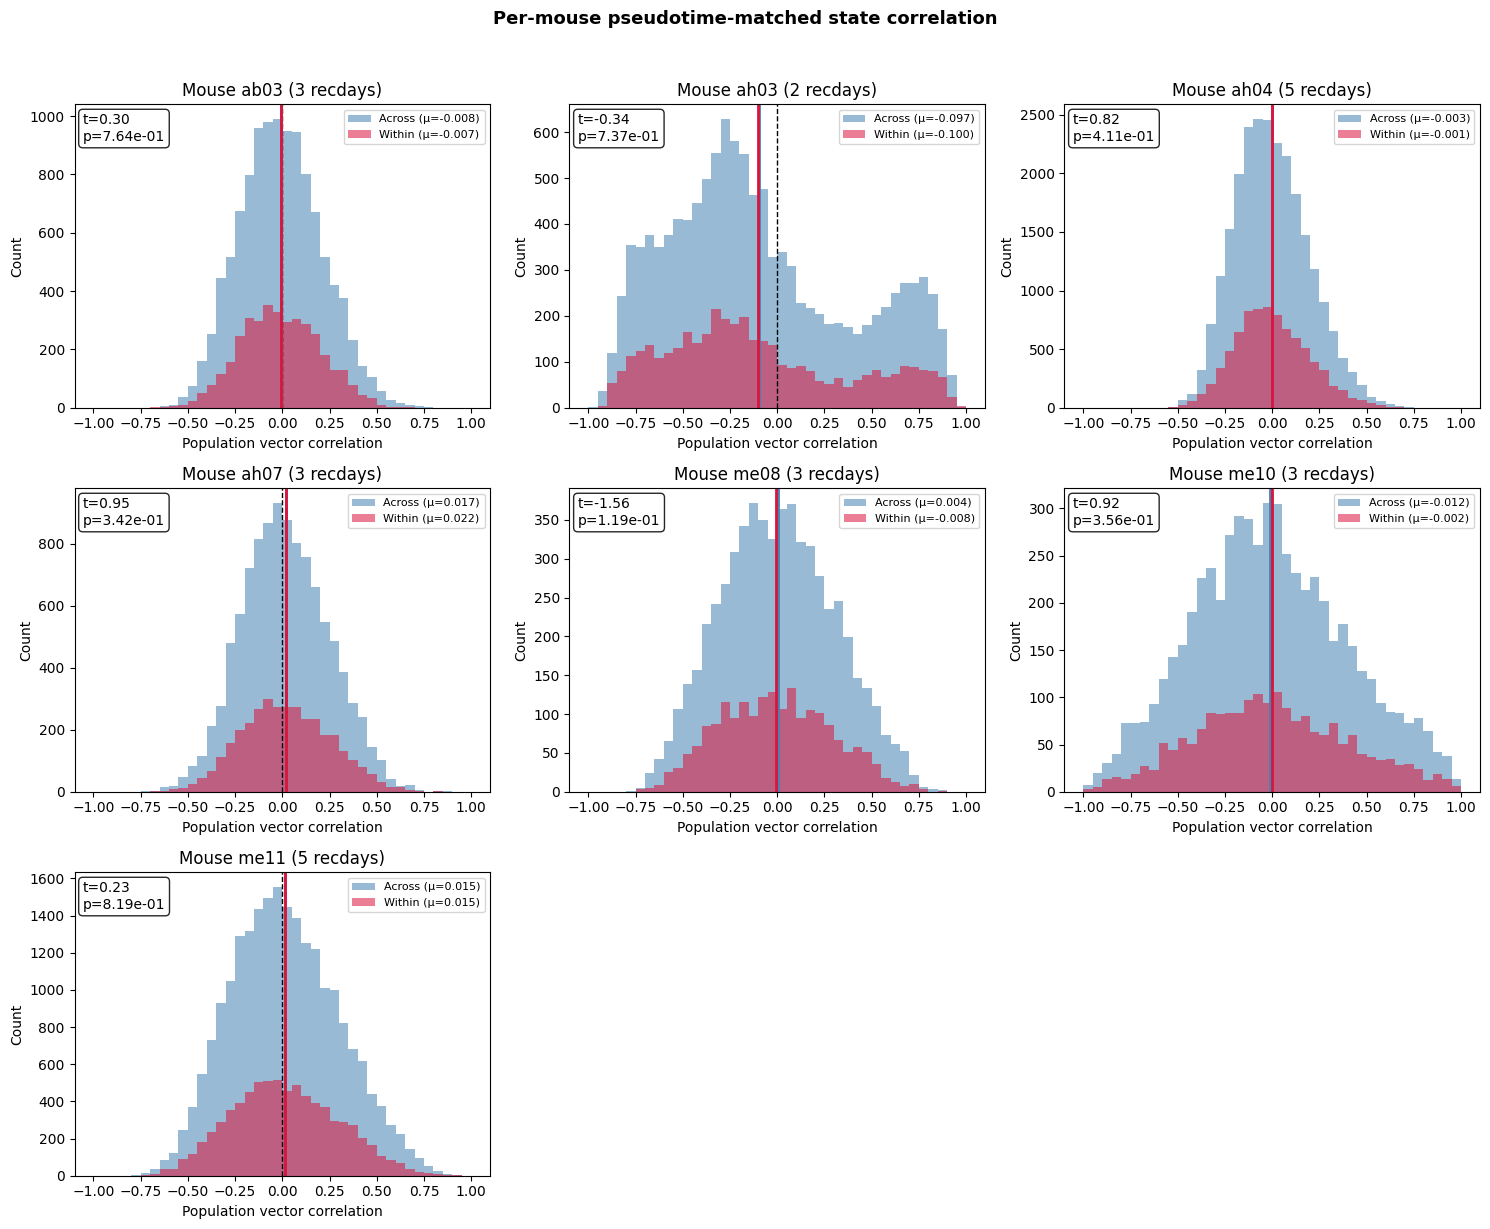

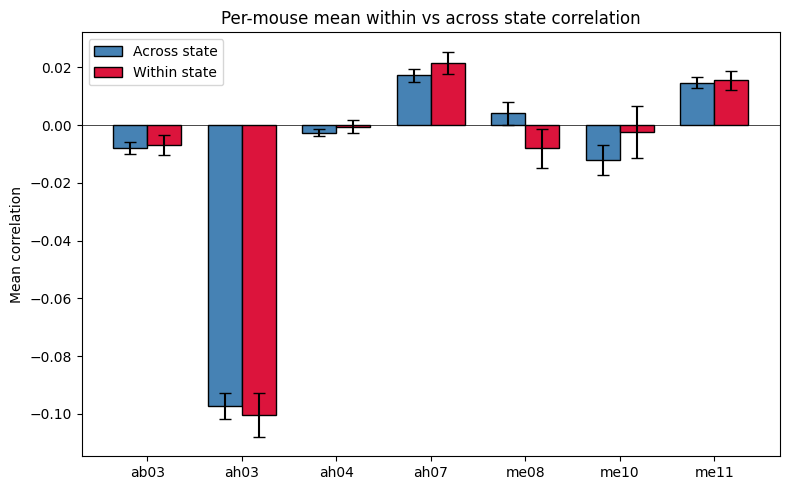


Per-mouse paired test (within - across): mean Δ=0.0004, t=0.17, p=8.73e-01  (n_mice=7)


In [13]:
# Per-mouse aggregation of pseudotime correlations.
from collections import defaultdict

# Group recdays by mouse identity (first '_' token of mouse_recday)
mouse_to_recdays = defaultdict(list)
for mr in per_recday_arrays:
    mouse = mr.split('_')[0]
    mouse_to_recdays[mouse].append(mr)

mice_sorted = sorted(mouse_to_recdays.keys())

# Concatenate within/across arrays per mouse
by_mouse = {}
for mouse in mice_sorted:
    w_all = np.concatenate([per_recday_arrays[mr][0] for mr in mouse_to_recdays[mouse]])
    a_all = np.concatenate([per_recday_arrays[mr][1] for mr in mouse_to_recdays[mouse]])
    by_mouse[mouse] = (w_all, a_all)
    print(f'  {mouse}: {len(mouse_to_recdays[mouse])} recdays, '
          f'within \u03bc={w_all.mean():.3f} (n={len(w_all)})  '
          f'across \u03bc={a_all.mean():.3f} (n={len(a_all)})')

# --- Figure 1: histogram grid (one panel per mouse) ---
n_mice = len(mice_sorted)
ncols = min(n_mice, 3)
nrows = (n_mice + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
bins = np.linspace(-1, 1, 41)
for i, mouse in enumerate(mice_sorted):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    w_arr, a_arr = by_mouse[mouse]
    ax.hist(a_arr, bins=bins, color='steelblue', alpha=0.55,
            label=f'Across (\u03bc={a_arr.mean():.3f})')
    ax.hist(w_arr, bins=bins, color='crimson', alpha=0.55,
            label=f'Within (\u03bc={w_arr.mean():.3f})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(a_arr.mean(), color='steelblue', linewidth=2)
    ax.axvline(w_arr.mean(), color='crimson', linewidth=2)
    t, p = st.ttest_ind(w_arr, a_arr)
    ax.text(0.02, 0.97, f't={t:.2f}\np={p:.2e}',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_title(f'Mouse {mouse} ({len(mouse_to_recdays[mouse])} recdays)')
    ax.set_xlabel('Population vector correlation')
    ax.set_ylabel('Count')
    ax.legend(loc='upper right', fontsize=8)
# Hide any unused axes
for j in range(n_mice, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis('off')
plt.suptitle('Per-mouse pseudotime-matched state correlation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 2: per-mouse bar chart of within/across means ---
fig, ax = plt.subplots(figsize=(8, 5))
w_mouse_means = [by_mouse[m][0].mean() for m in mice_sorted]
a_mouse_means = [by_mouse[m][1].mean() for m in mice_sorted]
w_mouse_sems = [by_mouse[m][0].std() / np.sqrt(len(by_mouse[m][0])) for m in mice_sorted]
a_mouse_sems = [by_mouse[m][1].std() / np.sqrt(len(by_mouse[m][1])) for m in mice_sorted]
x = np.arange(len(mice_sorted))
ax.bar(x - 0.18, a_mouse_means, yerr=a_mouse_sems, width=0.36,
       color='steelblue', label='Across state', edgecolor='black', capsize=4)
ax.bar(x + 0.18, w_mouse_means, yerr=w_mouse_sems, width=0.36,
       color='crimson', label='Within state', edgecolor='black', capsize=4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(mice_sorted)
ax.set_ylabel('Mean correlation')
ax.set_title('Per-mouse mean within vs across state correlation')
ax.legend()
plt.tight_layout()
plt.show()

# --- Per-mouse paired test (most conservative; one observation per mouse) ---
mouse_diffs = np.array(w_mouse_means) - np.array(a_mouse_means)
if len(mouse_diffs) >= 2:
    t_m, p_m = st.ttest_1samp(mouse_diffs, 0)
    print(f'\nPer-mouse paired test (within - across): '
          f'mean \u0394={mouse_diffs.mean():.4f}, t={t_m:.2f}, p={p_m:.2e}  (n_mice={len(mouse_diffs)})')
else:
    print(f'\nOnly {len(mouse_diffs)} mouse(s); paired test not meaningful.')

#### Aggregator: mean vs max per state window

The pseudotime analysis above used **mean** firing across each state window for the per-(trial, state) population vectors. The cell below reruns the cross-task analysis with **max** instead — useful when state-tuning is transient/punctate rather than sustained. Side-by-side comparison of pooled within vs across distributions under both aggregators.

Task is (8, 3, 6, 4)
Task is (7, 2, 8, 9)
Task is (8, 4, 3, 5)
Task is (9, 5, 2, 8)
Task is (4, 9, 3, 6)
Task is (9, 7, 8, 5)
ab03_01092023_02092023: 6 sessions, 63 neurons
  Session 0 (index 0): 28 trials, T=46527 samples
  Session 1 (index 1): 28 trials, T=47157 samples
  Session 2 (index 2): 32 trials, T=48597 samples
  Session 3 (index 3): 39 trials, T=47648 samples
  Session 4 (index 4): 27 trials, T=47725 samples
  Session 5 (index 5): 29 trials, T=47054 samples
(array([0, 1, 2, 3, 4, 5]), array([112, 112, 128, 156, 108, 116]))
  Dataset: 732 samples (0 skipped) from 732 (trial, state) pairs
Task is (5, 6, 4, 8)
Task is (4, 7, 2, 3)
Task is (3, 6, 7, 9)
Task is (6, 9, 2, 1)
Task is (9, 5, 8, 7)
Task is (7, 1, 5, 3)
ab03_05092023_06092023: 6 sessions, 64 neurons
  Session 0 (index 0): 29 trials, T=47677 samples
  Session 1 (index 1): 18 trials, T=44462 samples
  Session 2 (index 2): 13 trials, T=46532 samples
  Session 4 (index 3): 28 trials, T=46707 samples
  Session 5 (index 4):

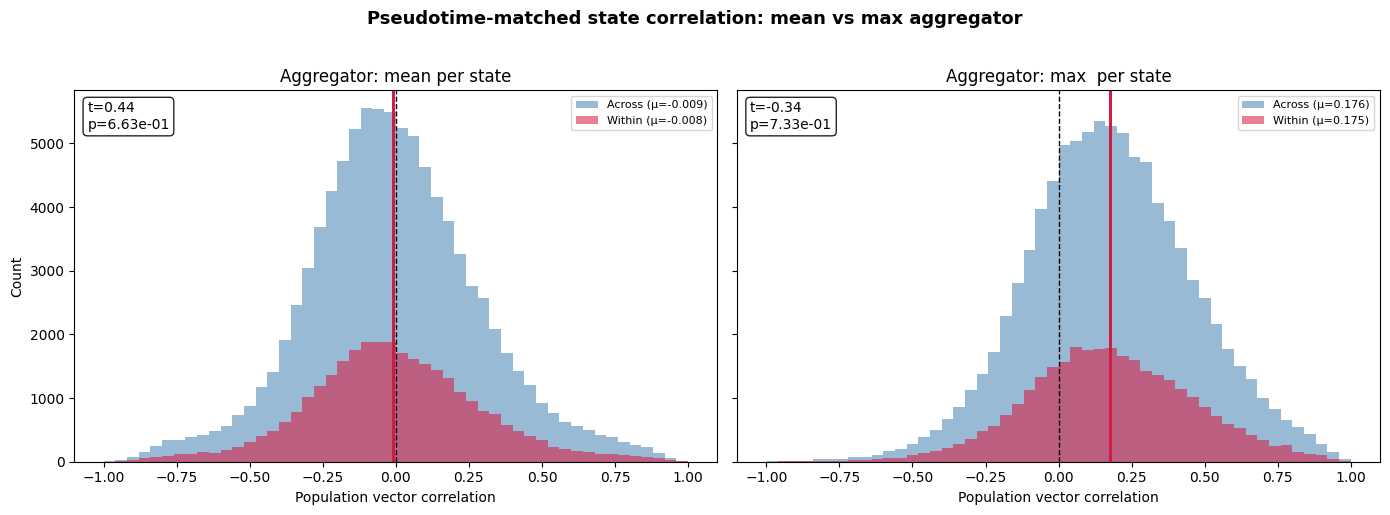

In [14]:
# Pseudotime-matched correlation with MAX aggregation per state (vs the MEAN above).
# Uses build_trialbins_dataset(..., aggregator='max').

reload(lda_state_analysis_trialbins)
from lda_state_analysis_trialbins import (
    build_trialbins_dataset,
    compute_pseudotime_state_correlations,
)

pooled_within_max = []
pooled_across_max = []
for mr in mouse_recdays:
    try:
        X, y_state, sess_id, trial_id, _, _ = build_trialbins_dataset(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            neuron_subset=None,
            aggregator='max',
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')
        continue
    within, across = compute_pseudotime_state_correlations(X, y_state, sess_id, trial_id)
    if within and across:
        pooled_within_max.append(np.array([d['corr'] for d in within]))
        pooled_across_max.append(np.array([d['corr'] for d in across]))

pooled_within_max = np.concatenate(pooled_within_max)
pooled_across_max = np.concatenate(pooled_across_max)

# Side-by-side: mean (re-uses pooled_within / pooled_across from cell 14) vs max
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
bins = np.linspace(-1, 1, 51)
for ax, (lbl, w, a) in zip(axes, [
        ('mean per state', pooled_within, pooled_across),
        ('max  per state', pooled_within_max, pooled_across_max)]):
    ax.hist(a, bins=bins, color='steelblue', alpha=0.55,
            label=f'Across (\u03bc={a.mean():.3f})')
    ax.hist(w, bins=bins, color='crimson', alpha=0.55,
            label=f'Within (\u03bc={w.mean():.3f})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(a.mean(), color='steelblue', linewidth=2)
    ax.axvline(w.mean(), color='crimson', linewidth=2)
    t, p = st.ttest_ind(w, a)
    ax.text(0.02, 0.97, f't={t:.2f}\np={p:.2e}',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_xlabel('Population vector correlation')
    ax.set_title(f'Aggregator: {lbl}')
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('Count')
plt.suptitle('Pseudotime-matched state correlation: mean vs max aggregator',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Per goal-progress bin breakdown (early / middle / late)

Split each state's 90-bin window into 3 equal sub-windows (goal-progress bins). Rerun the pseudotime-matched within-vs-across-state correlation analysis separately within each gp bin. Tests whether the within > across pattern holds across all phases of goal progress (early/middle/late within each state), or is concentrated at a particular phase (e.g., reward approach).

Uses `build_trialbins_gp_dataset` from `lda_state_analysis_trialbins.py`, which extracts one population vector per (trial, state, gp_bin). The cell below filters by gp bin and reuses `compute_pseudotime_state_correlations` for the within/across correlation logic.

  GP dataset: 2196 samples (0 skipped); 3 gp bins per state
  GP dataset: 1428 samples (0 skipped); 3 gp bins per state
  GP dataset: 1668 samples (0 skipped); 3 gp bins per state
  GP dataset: 2580 samples (0 skipped); 3 gp bins per state
  GP dataset: 2880 samples (0 skipped); 3 gp bins per state
  GP dataset: 2016 samples (0 skipped); 3 gp bins per state
  GP dataset: 2184 samples (0 skipped); 3 gp bins per state
  GP dataset: 2040 samples (0 skipped); 3 gp bins per state
  GP dataset: 2508 samples (0 skipped); 3 gp bins per state
  GP dataset: 2544 samples (0 skipped); 3 gp bins per state
  GP dataset: 1728 samples (0 skipped); 3 gp bins per state
  GP dataset: 1884 samples (0 skipped); 3 gp bins per state
  GP dataset: 1656 samples (0 skipped); 3 gp bins per state
  GP dataset: 996 samples (0 skipped); 3 gp bins per state
  GP dataset: 972 samples (0 skipped); 3 gp bins per state
  GP dataset: 912 samples (0 skipped); 3 gp bins per state
  GP dataset: 1404 samples (0 skipped); 3 g

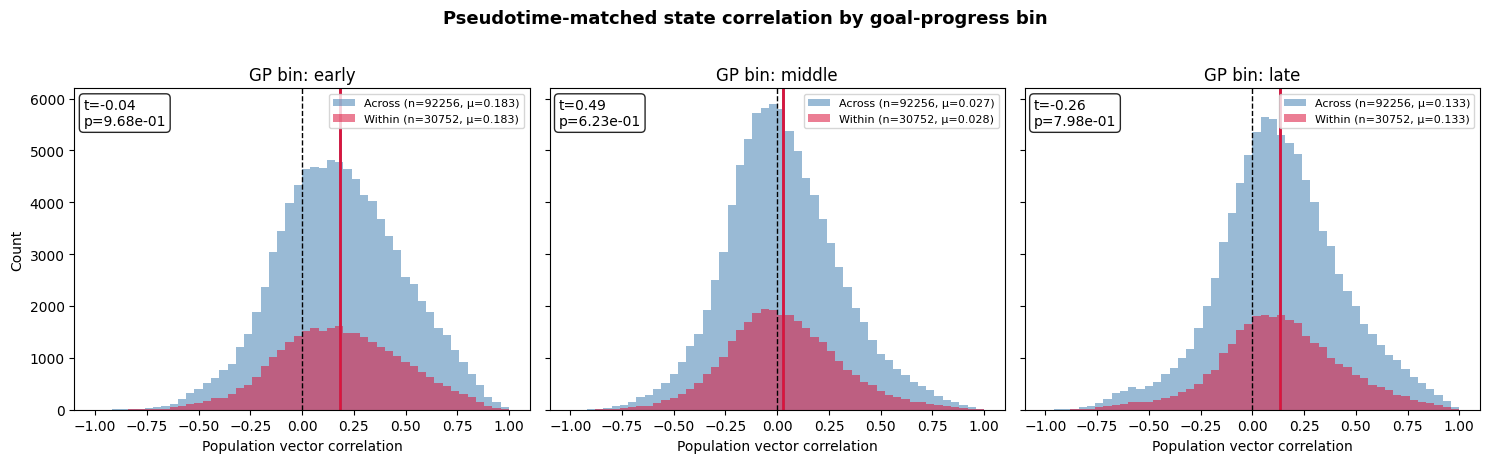


Per-mouse paired test (within - across) by gp bin:
  early   : n_mice=7  Δ=-0.0004  t=-0.21  p=8.43e-01
  middle  : n_mice=7  Δ=-0.0003  t=-0.13  p=9.01e-01
  late    : n_mice=7  Δ=-0.0004  t=-0.12  p=9.05e-01


In [15]:
# Pseudotime-matched state correlation, broken down by goal-progress bin.
from lda_state_analysis_trialbins import build_trialbins_gp_dataset

GP_LABELS = ['early', 'middle', 'late']
NUM_GP_BINS = 3

pooled_by_gp = {gp: {'within': [], 'across': []} for gp in range(NUM_GP_BINS)}
per_recday_by_gp = {gp: {} for gp in range(NUM_GP_BINS)}

for mr in mouse_recdays:
    try:
        X, y_state, y_gp, sess_id, trial_id, _ = build_trialbins_gp_dataset(
            data_dic, mr,
            valid_sessions=valid_sessions_dic[mr],
            neuron_subset=None,
            num_gp_bins=NUM_GP_BINS,
        )
    except Exception as e:
        print(f'  {mr}: skipped ({e})')
        continue

    for gp in range(NUM_GP_BINS):
        mask = y_gp == gp
        if mask.sum() == 0:
            continue
        within, across = compute_pseudotime_state_correlations(
            X[mask], y_state[mask], sess_id[mask], trial_id[mask]
        )
        if not within or not across:
            continue
        w = np.array([d['corr'] for d in within])
        a = np.array([d['corr'] for d in across])
        pooled_by_gp[gp]['within'].append(w)
        pooled_by_gp[gp]['across'].append(a)
        per_recday_by_gp[gp][mr] = (w, a)

# --- Figure: pooled distributions per gp bin (1 x 3) ---
fig, axes = plt.subplots(1, NUM_GP_BINS, figsize=(5 * NUM_GP_BINS, 4.5), sharey=True)
bins = np.linspace(-1, 1, 51)
for gp, gp_label in enumerate(GP_LABELS):
    ax = axes[gp]
    if not pooled_by_gp[gp]['within']:
        ax.set_title(f'{gp_label} - no data')
        continue
    w = np.concatenate(pooled_by_gp[gp]['within'])
    a = np.concatenate(pooled_by_gp[gp]['across'])
    ax.hist(a, bins=bins, color='steelblue', alpha=0.55,
            label=f'Across (n={len(a)}, \u03bc={a.mean():.3f})')
    ax.hist(w, bins=bins, color='crimson', alpha=0.55,
            label=f'Within (n={len(w)}, \u03bc={w.mean():.3f})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(a.mean(), color='steelblue', linewidth=2)
    ax.axvline(w.mean(), color='crimson', linewidth=2)
    t, p = st.ttest_ind(w, a)
    ax.text(0.02, 0.97, f't={t:.2f}\np={p:.2e}',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_xlabel('Population vector correlation')
    if gp == 0:
        ax.set_ylabel('Count')
    ax.set_title(f'GP bin: {gp_label}')
    ax.legend(loc='upper right', fontsize=8)
plt.suptitle('Pseudotime-matched state correlation by goal-progress bin',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Per-mouse paired test per gp bin (most conservative inference) ---
print('\nPer-mouse paired test (within - across) by gp bin:')
for gp in range(NUM_GP_BINS):
    by_mr = per_recday_by_gp[gp]
    if not by_mr:
        print(f'  {GP_LABELS[gp]:8s}: no data')
        continue
    mouse_diffs = []
    for mouse in mice_sorted:
        recdays_m = [mr for mr in by_mr if mr.startswith(mouse + '_')]
        if not recdays_m:
            continue
        w_m = np.concatenate([by_mr[mr][0] for mr in recdays_m])
        a_m = np.concatenate([by_mr[mr][1] for mr in recdays_m])
        mouse_diffs.append(w_m.mean() - a_m.mean())
    md_arr = np.array(mouse_diffs)
    if len(md_arr) >= 2:
        t_m, p_m = st.ttest_1samp(md_arr, 0)
        print(f'  {GP_LABELS[gp]:8s}: n_mice={len(md_arr)}  \u0394={md_arr.mean():.4f}  '
              f't={t_m:.2f}  p={p_m:.2e}')
    else:
        print(f'  {GP_LABELS[gp]:8s}: only {len(md_arr)} mouse(s); skipped')

#### Per-mouse × goal-progress breakdown

Same goal-progress-binned within-vs-across-state analysis as the cell above, but broken out per mouse. Tests whether the phase-specificity of state tuning (if any) is consistent across animals or driven by a subset. Uses the `per_recday_by_gp` data already computed above (no re-fitting).

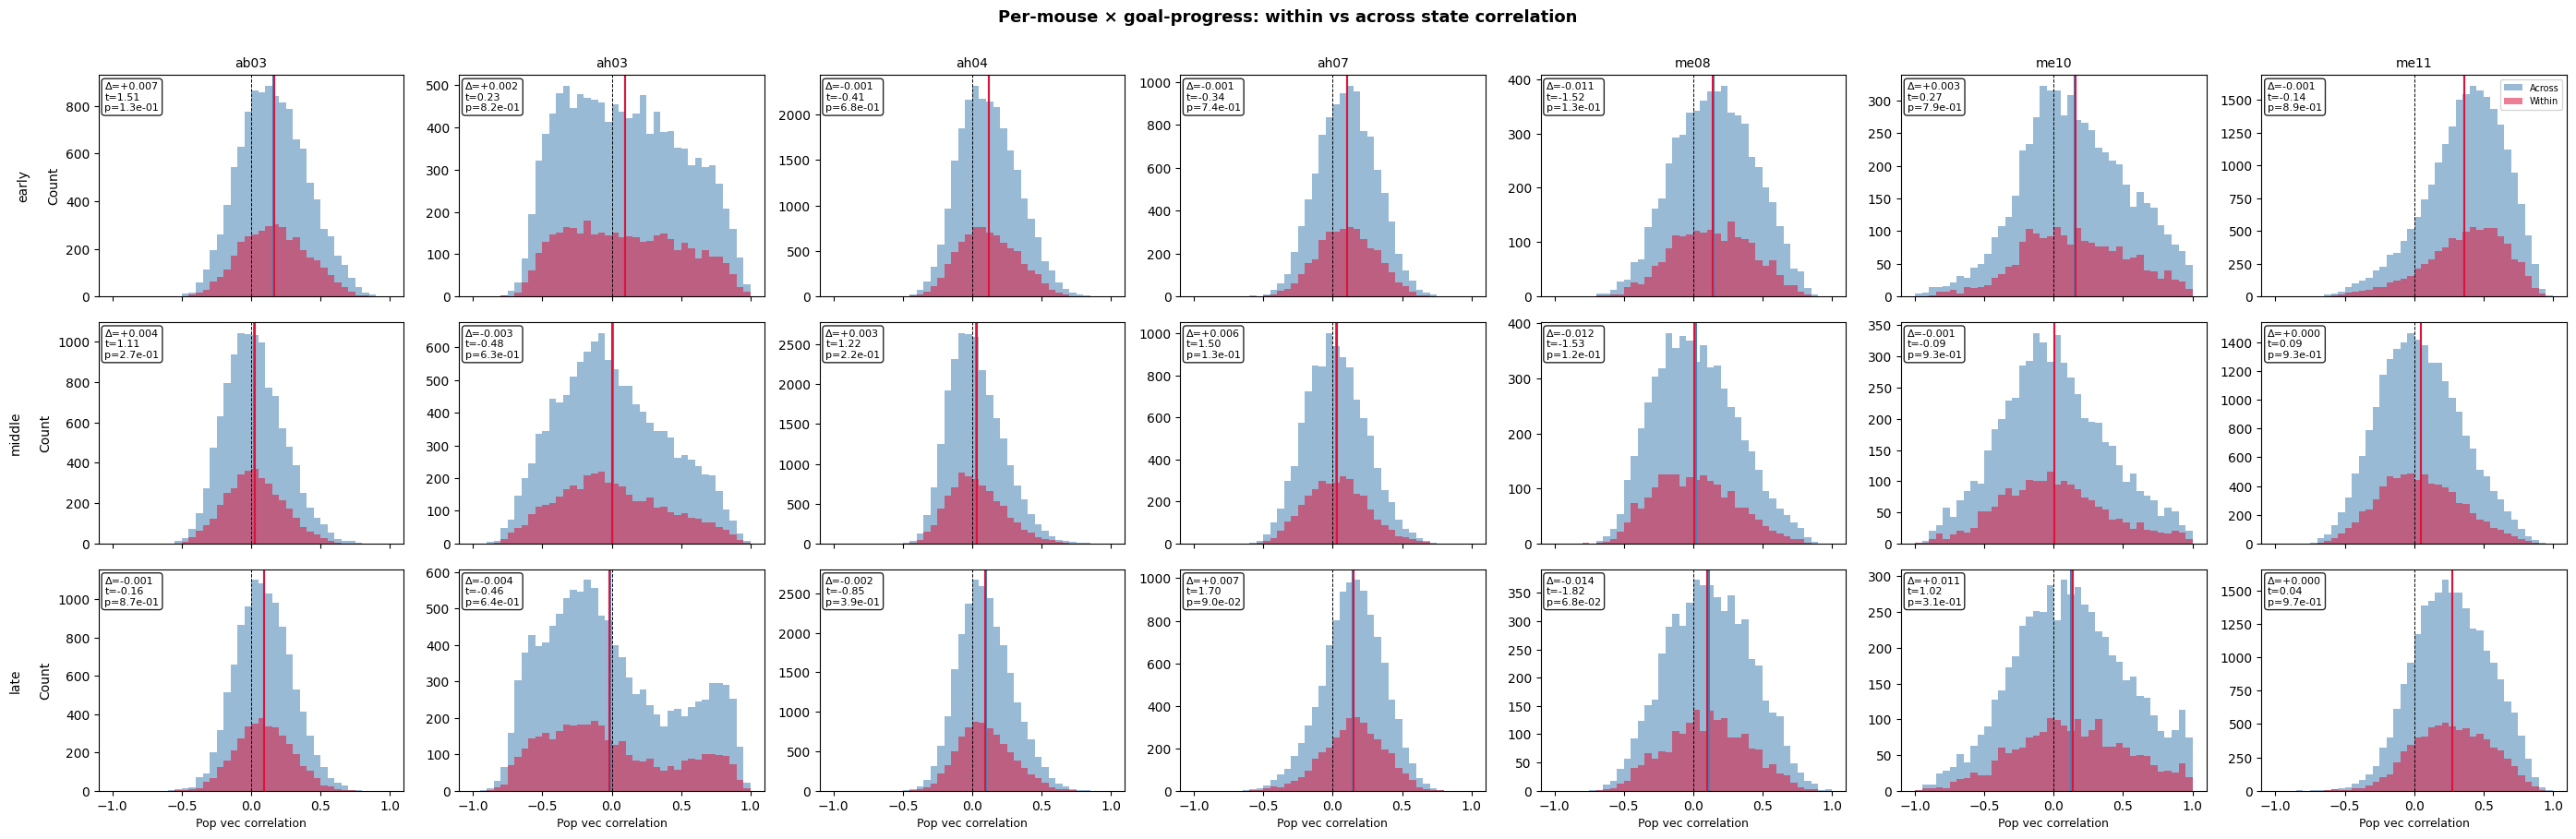

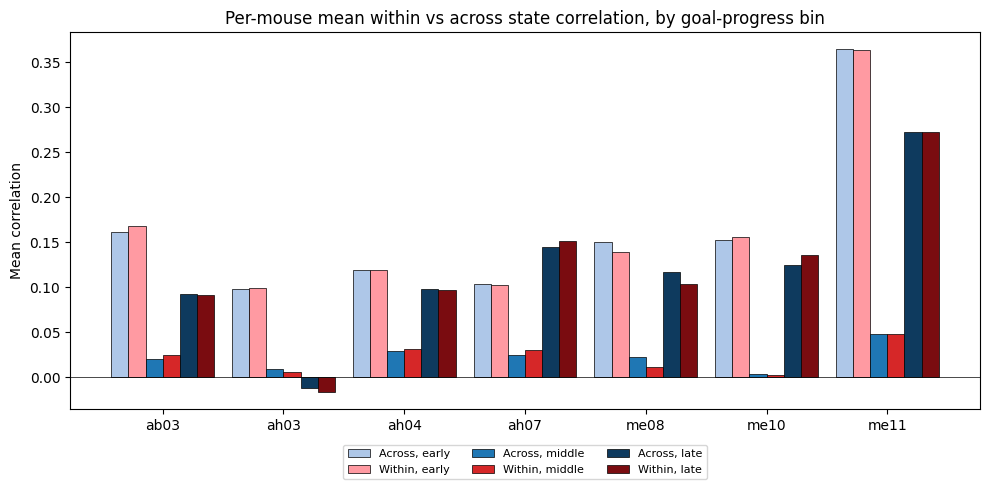

Per-mouse Δ (within - across) by gp bin:
  mouse        early     middle       late
  ab03       +0.0068    +0.0044    -0.0006
  ah03       +0.0017    -0.0034    -0.0039
  ah04       -0.0011    +0.0030    -0.0021
  ah07       -0.0013    +0.0062    +0.0071
  me08       -0.0112    -0.0117    -0.0139
  me10       +0.0027    -0.0009    +0.0107
  me11       -0.0005    +0.0003    +0.0001


In [16]:
# Per-mouse × goal-progress aggregation. Reuses per_recday_by_gp from the cell above
# and mice_sorted from the per-mouse cell. No re-extraction needed.

by_mouse_gp = {gp: {} for gp in range(NUM_GP_BINS)}  # {gp: {mouse: (w, a)}}
for gp in range(NUM_GP_BINS):
    for mouse in mice_sorted:
        recdays_m = [mr for mr in per_recday_by_gp[gp] if mr.startswith(mouse + '_')]
        if not recdays_m:
            continue
        w = np.concatenate([per_recday_by_gp[gp][mr][0] for mr in recdays_m])
        a = np.concatenate([per_recday_by_gp[gp][mr][1] for mr in recdays_m])
        by_mouse_gp[gp][mouse] = (w, a)

# --- Figure 1: histogram grid (rows = gp bin, cols = mouse) ---
n_mice = len(mice_sorted)
fig, axes = plt.subplots(NUM_GP_BINS, n_mice, figsize=(4 * n_mice, 3 * NUM_GP_BINS),
                         sharex=True, squeeze=False)
bins = np.linspace(-1, 1, 41)
for gp, gp_label in enumerate(GP_LABELS):
    for col, mouse in enumerate(mice_sorted):
        ax = axes[gp, col]
        if mouse not in by_mouse_gp[gp]:
            ax.set_title(f'{mouse}\n{gp_label} (no data)', fontsize=9)
            ax.axis('off')
            continue
        w, a = by_mouse_gp[gp][mouse]
        ax.hist(a, bins=bins, color='steelblue', alpha=0.55, label='Across')
        ax.hist(w, bins=bins, color='crimson', alpha=0.55, label='Within')
        ax.axvline(0, color='black', linestyle='--', linewidth=0.7)
        ax.axvline(a.mean(), color='steelblue', linewidth=1.5)
        ax.axvline(w.mean(), color='crimson', linewidth=1.5)
        t, p = st.ttest_ind(w, a)
        ax.text(0.02, 0.97,
                f'\u0394={w.mean() - a.mean():+.3f}\nt={t:.2f}\np={p:.1e}',
                transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        if gp == 0:
            ax.set_title(f'{mouse}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{gp_label}\n\nCount', fontsize=10)
        if gp == NUM_GP_BINS - 1:
            ax.set_xlabel('Pop vec correlation', fontsize=9)
        if gp == 0 and col == n_mice - 1:
            ax.legend(loc='upper right', fontsize=7)
plt.suptitle('Per-mouse × goal-progress: within vs across state correlation',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# --- Figure 2: per-mouse grouped bar chart (within/across × gp bin) ---
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.85 / (2 * NUM_GP_BINS)
x = np.arange(n_mice)
gp_colors_within = ['#ff9aa2', '#d62728', '#7a0c10']
gp_colors_across = ['#aec7e8', '#1f77b4', '#0e3a5e']
for gp, gp_label in enumerate(GP_LABELS):
    a_means = [by_mouse_gp[gp][m][1].mean() if m in by_mouse_gp[gp] else np.nan for m in mice_sorted]
    w_means = [by_mouse_gp[gp][m][0].mean() if m in by_mouse_gp[gp] else np.nan for m in mice_sorted]
    offset_a = (gp * 2 - NUM_GP_BINS + 0.5) * bar_width
    offset_w = (gp * 2 - NUM_GP_BINS + 1.5) * bar_width
    ax.bar(x + offset_a, a_means, width=bar_width, color=gp_colors_across[gp],
           edgecolor='black', linewidth=0.5, label=f'Across, {gp_label}')
    ax.bar(x + offset_w, w_means, width=bar_width, color=gp_colors_within[gp],
           edgecolor='black', linewidth=0.5, label=f'Within, {gp_label}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(mice_sorted)
ax.set_ylabel('Mean correlation')
ax.set_title('Per-mouse mean within vs across state correlation, by goal-progress bin')
ax.legend(ncol=3, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

# --- Per-mouse Δ printout (within - across) by gp bin ---
print('Per-mouse \u0394 (within - across) by gp bin:')
print(f"  {'mouse':6s}  " + ' '.join(f'{lab:>10s}' for lab in GP_LABELS))
for mouse in mice_sorted:
    cells = []
    for gp in range(NUM_GP_BINS):
        if mouse in by_mouse_gp[gp]:
            w, a = by_mouse_gp[gp][mouse]
            cells.append(f'{w.mean() - a.mean():+.4f}')
        else:
            cells.append('     ---')
    print(f"  {mouse:6s}  " + ' '.join(f'{c:>10s}' for c in cells))

## Goal-progress LDA

Splits each (trial, state) into early / middle / late goal-progress bins and fits a separate 4-class LDA within each bin. Useful for asking whether state representation changes across the approach-to-reward trajectory.


Goal-progress LDA analysis: me11_12122021_13122021
Sessions: [0, 1, 3, 6, 8]
Task is (5, 8, 4, 6)
Task is (1, 3, 2, 5)
Task is (9, 5, 4, 2)
Task is (3, 5, 8, 2)
Task is (2, 3, 5, 7)
me11_12122021_13122021: 5 sessions, 12 neurons
  Session 0 (index 0): 15 trials, T=41359 samples
  Session 1 (index 1): 15 trials, T=45216 samples
  Session 3 (index 2): 16 trials, T=42901 samples
  Session 6 (index 3): 14 trials, T=42208 samples
  Session 8 (index 4): 25 trials, T=46135 samples
  Dataset: 1020 samples (0 skipped) from 1020 (trial, state, bin) triples
    early: 340 samples
    middle: 340 samples
    late: 340 samples

------------------------------------------------------------
  Progress bin: EARLY
------------------------------------------------------------
  PCA: keeping 5/12 PCs (77.1% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 340
Number of LDA components: 3
Explained variance ratio: [0.61602796 0.29433358 0.08963847]


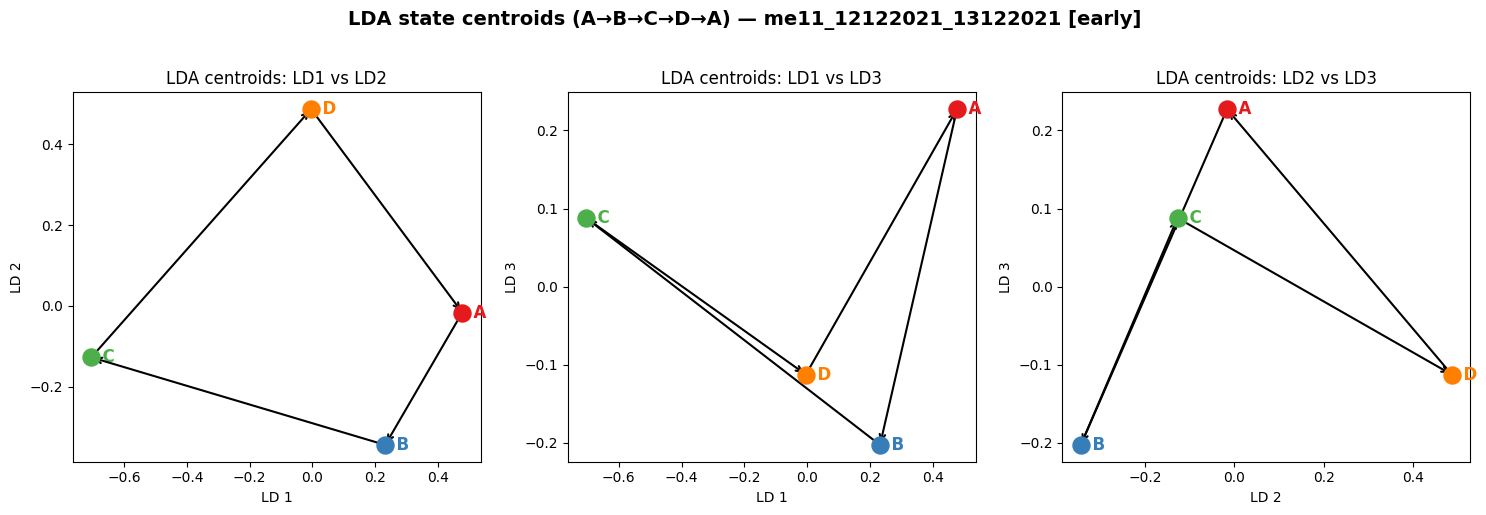

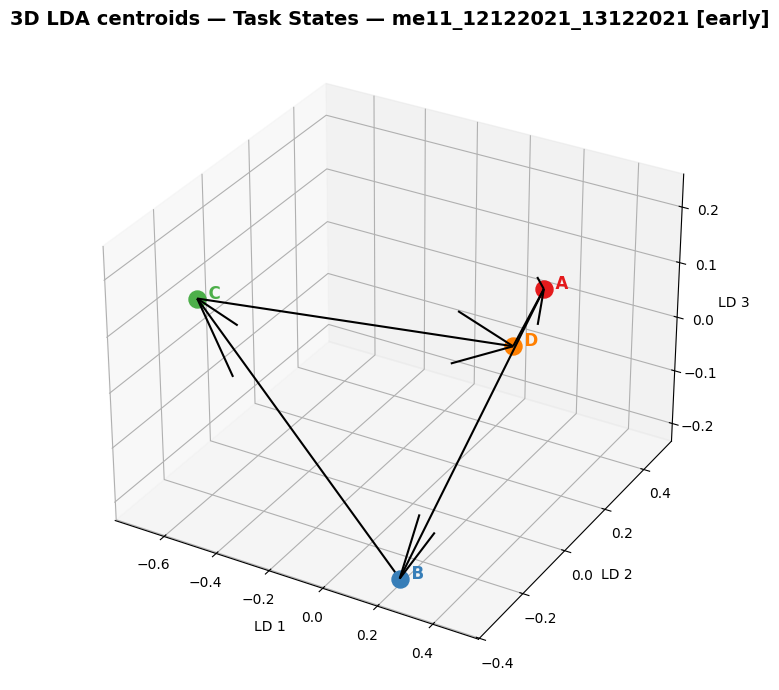

Working with sessions [0 1 2 3 4] (total 5)
Leave-one-session-out CV (5 sessions)
Real CV balanced accuracy: 0.339
Null: 0.248 ± 0.023
p = 0.0000


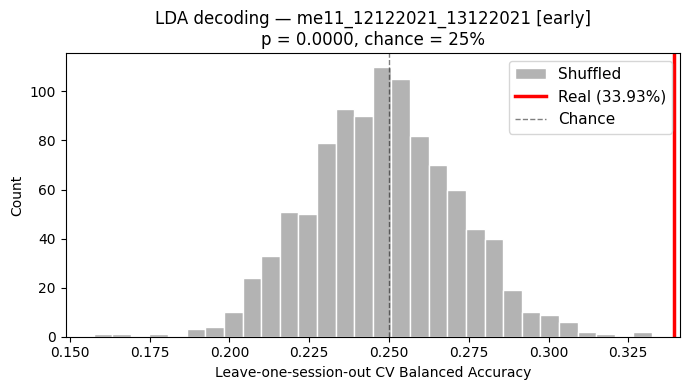


------------------------------------------------------------
  Progress bin: MIDDLE
------------------------------------------------------------
  PCA: keeping 6/12 PCs (77.2% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 340
Number of LDA components: 3
Explained variance ratio: [0.69176254 0.21139105 0.09684641]


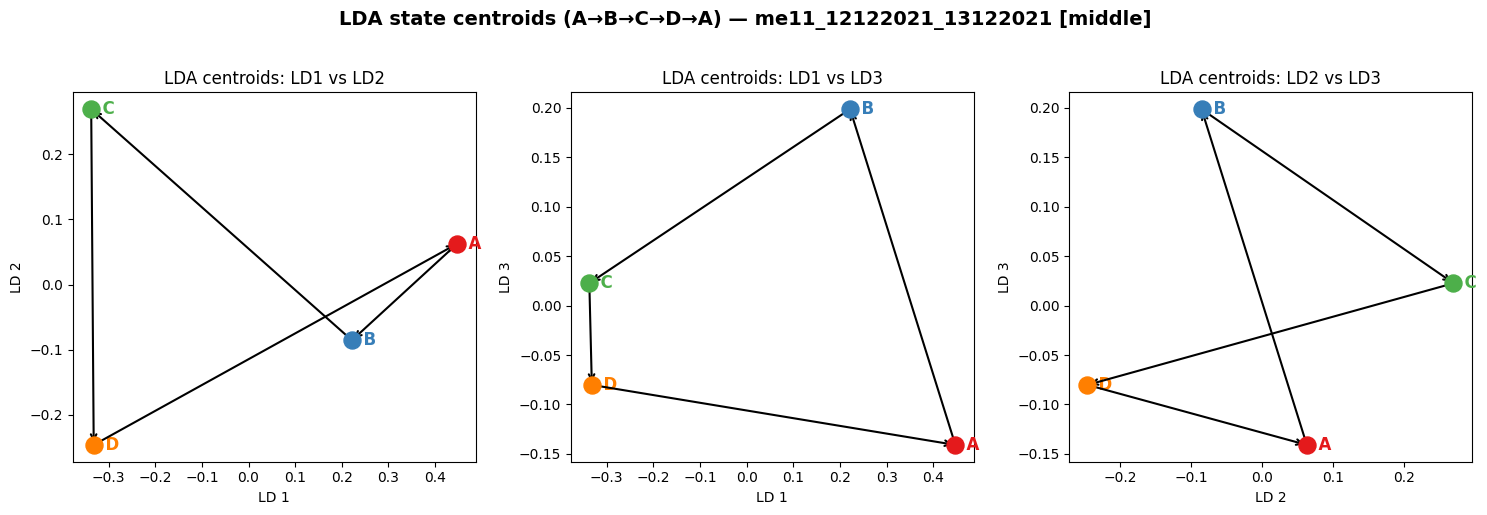

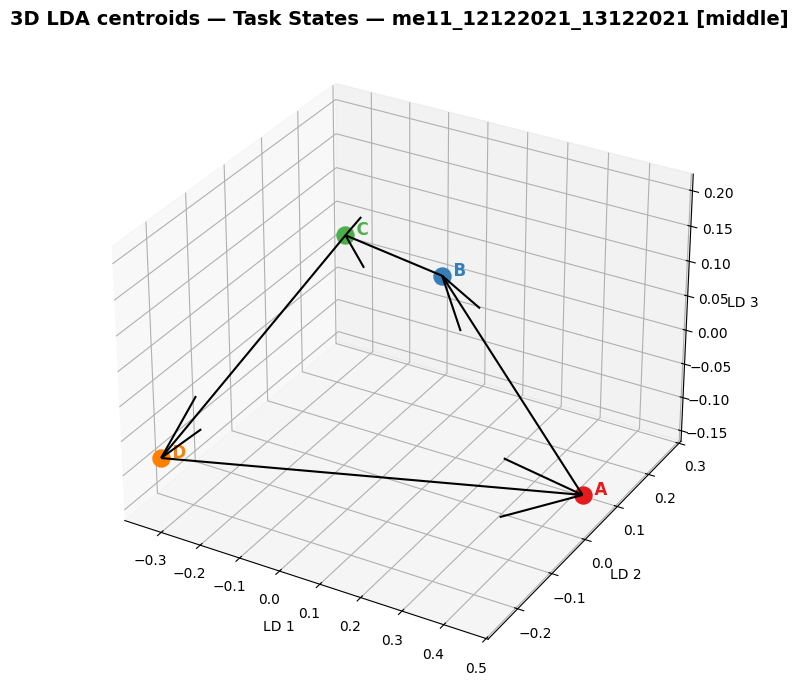

Working with sessions [0 1 2 3 4] (total 5)
Leave-one-session-out CV (5 sessions)
Real CV balanced accuracy: 0.256
Null: 0.250 ± 0.025
p = 0.4070


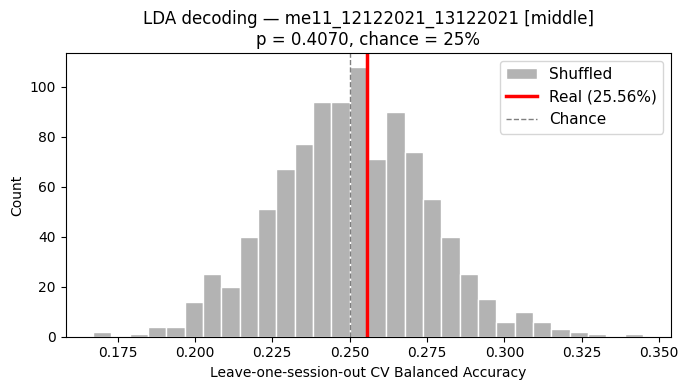


------------------------------------------------------------
  Progress bin: LATE
------------------------------------------------------------
  PCA: keeping 6/12 PCs (77.6% cumulative variance)
LDA fitted to separate task states A, B, C, D
Number of samples: 340
Number of LDA components: 3
Explained variance ratio: [0.75295502 0.20048989 0.04655509]


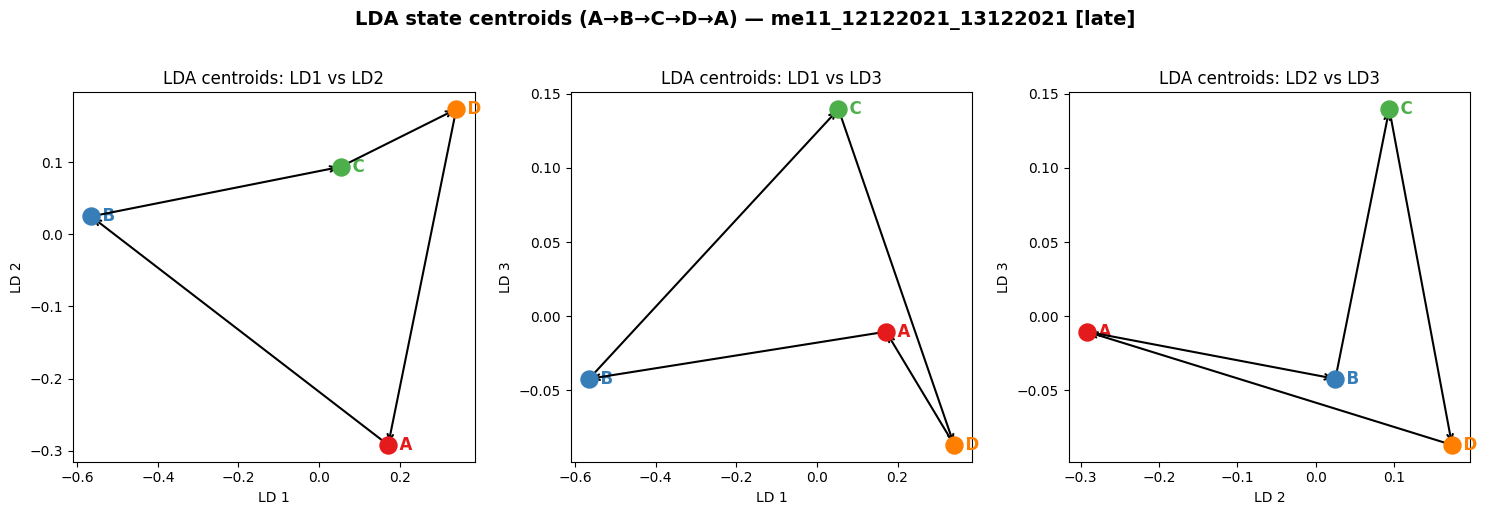

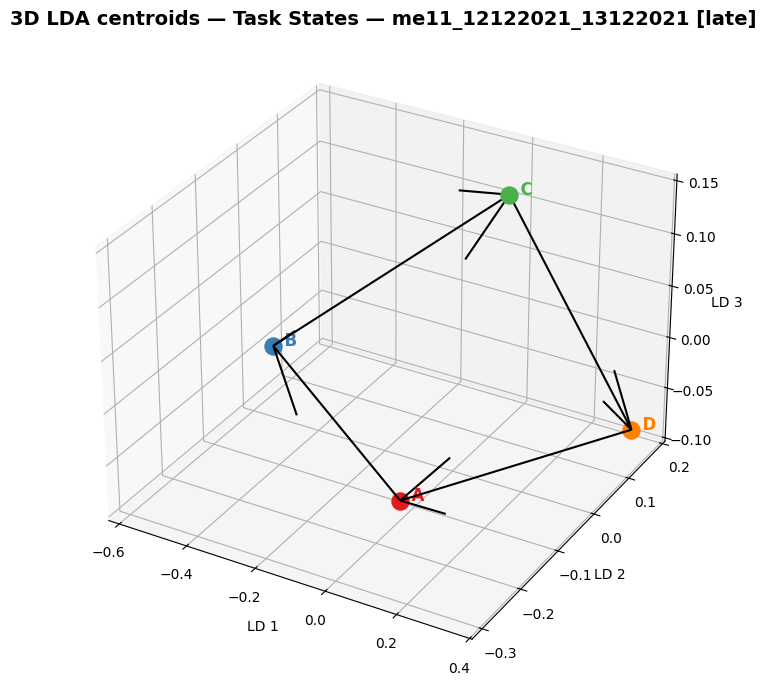

Working with sessions [0 1 2 3 4] (total 5)
Leave-one-session-out CV (5 sessions)
Real CV balanced accuracy: 0.214
Null: 0.250 ± 0.024
p = 0.9280


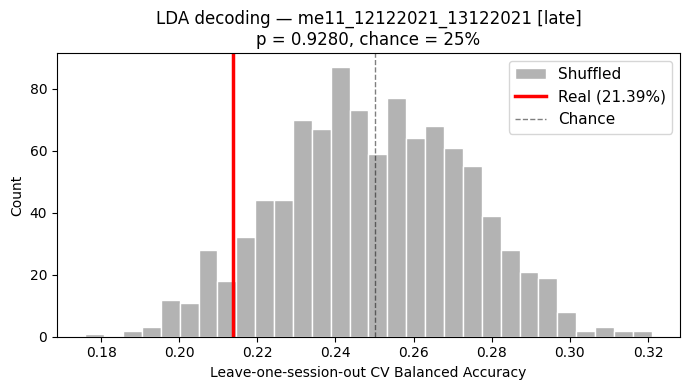


Summary — me11_12122021_13122021
  early   : acc=0.339  p=0.000  n=340 samples
  middle  : acc=0.256  p=0.407  n=340 samples
  late    : acc=0.214  p=0.928  n=340 samples

Computing null centroids with 1000 circular label rolls...


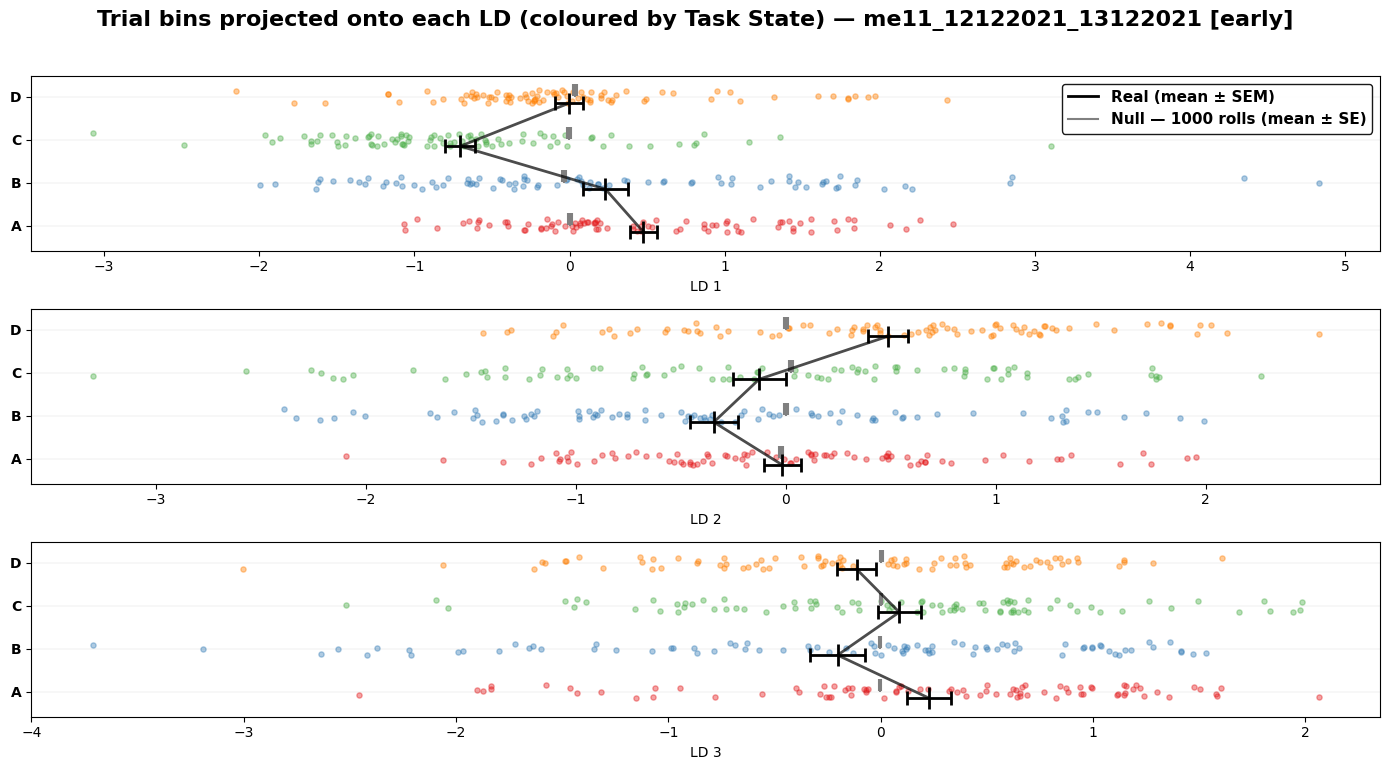

Computing null centroids with 1000 circular label rolls...


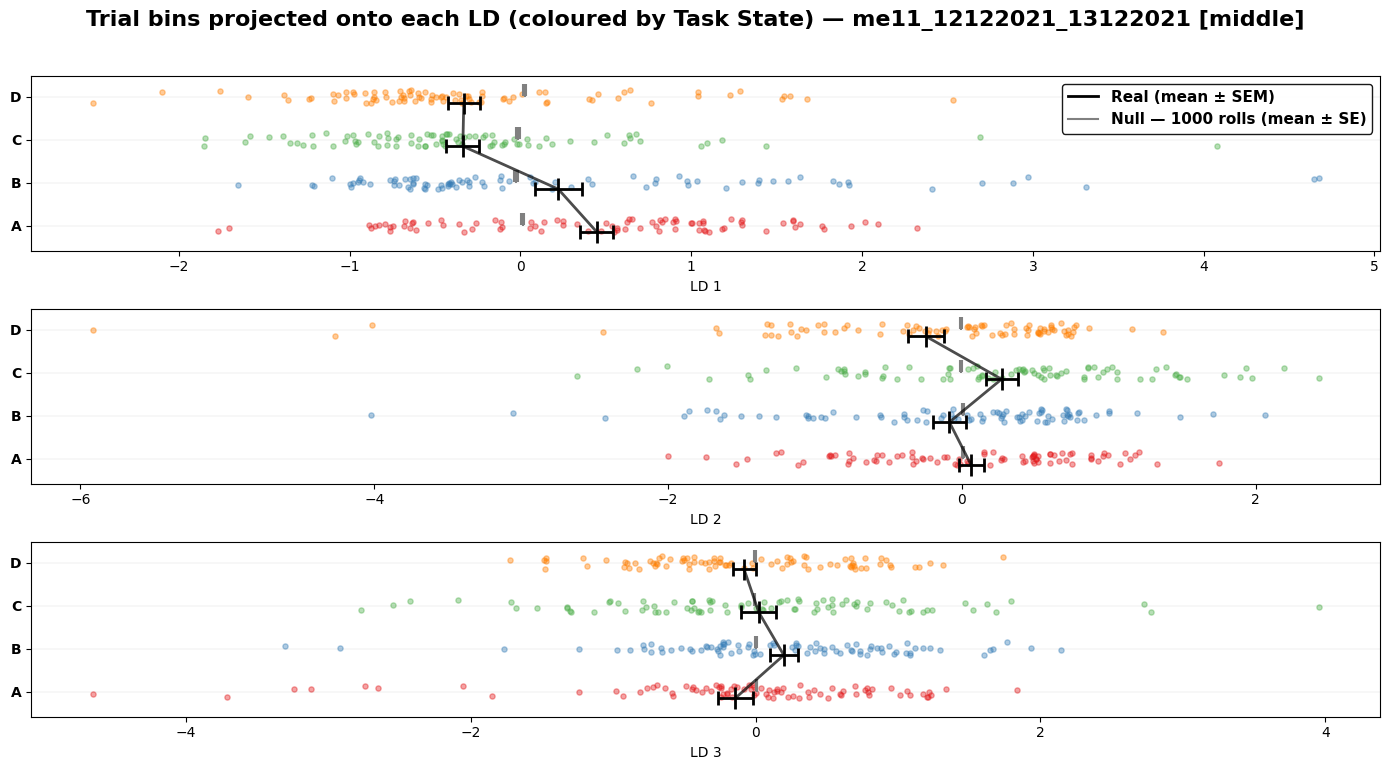

Computing null centroids with 1000 circular label rolls...


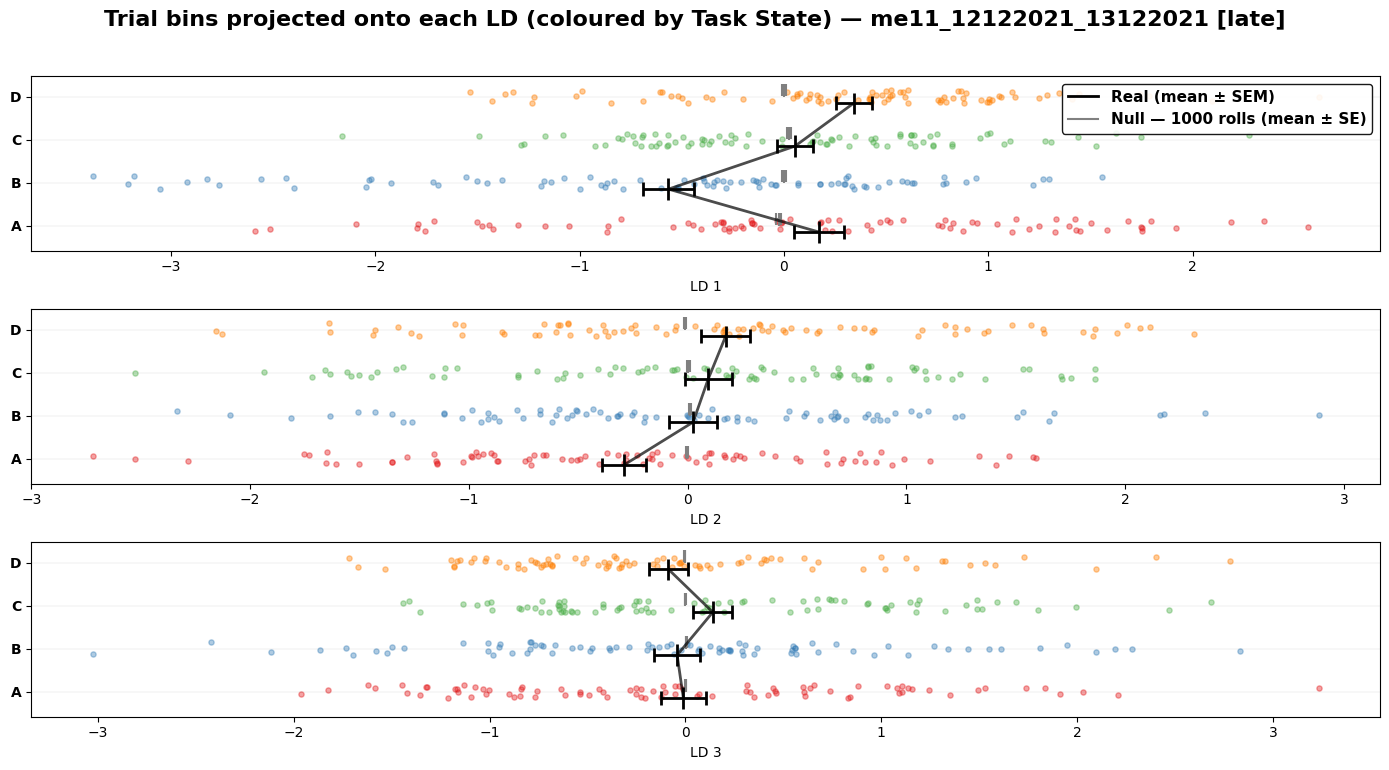

In [17]:
import lda_state_analysis_goalprogress
reload(lda_state_analysis_goalprogress)
from lda_state_analysis_goalprogress import run_goalprogress_lda_analysis

gp_results = run_goalprogress_lda_analysis(
    data_dic, mouse_recday,
    valid_sessions=valid_sessions_dic[mouse_recday],
    neuron_subset=None,
)

for bin_label, r in gp_results.items():
    if r is not None:
        plot_ld_projections(r['X_state_ld'], r['y_state'],
                            EVENT_LABELS, EVENT_COLOURS,
                            f'{mouse_recday} [{bin_label}]')

## Reward × goal-progress LDA

Joint decoding analysis: fits LDA to discriminate reward number AND goal-progress phase. Run across all mouse_recdays and aggregate confusion matrices.

In [ ]:
# Joint LDA on the trial x goal-progress conjunction (30 classes, the 4 states of a trial are
# 4 samples of one class), read out on held-out sessions for both variables. RUN_MODE 'load'
# reads the pickle written on the cluster by code/run_lda_reward_progress.py
#   (sbatch sbatch_files/lda_reward_progress.sbatch pfc); 'run' recomputes here (slow: 1000
#   circular-shift refits per recday -- not for all recdays inside the 64 GB interactive cgroup).
RUN_MODE = 'load'

import lda_reward_goalprogress
reload(lda_reward_goalprogress)
from lda_reward_goalprogress import (
    run_reward_progress_lda_analysis,
    run_joint_lda_readout,
    load_reward_progress_results,
    reward_progress_table,
    plot_reward_progress_ld_scatter,
    _plot_confusion_matrix,
)

if RUN_MODE == 'load':
    payload = load_reward_progress_results('pfc')
    results_by_recday, readout = payload['results_by_recday'], payload['readout']
    print(f"loaded {len(readout)} recdays ({payload['conjunction']}, min_trials={payload['min_trials']}, "
          f"{payload['n_shuffles']} shuffles); skipped: {payload['skipped']}")
else:
    results_by_recday, readout = {}, {}
    for mr in mouse_recdays:
        res = run_reward_progress_lda_analysis(data_dic, mr, valid_sessions=valid_sessions_dic[mr],
                                               min_trials=10, conjunction='trial_progress', plot=False)
        if res is None:
            continue
        results_by_recday[mr] = res
        readout[mr] = run_joint_lda_readout(res, n_shuffles=1000)
    payload = dict(dataset='pfc', conjunction='trial_progress', min_trials=10, n_shuffles=1000,
                   results_by_recday=results_by_recday, readout=readout, skipped={})

table = reward_progress_table(payload)
display(table[['recday', 'n_neurons', 'n_pcs', 'n_classes', 'key_mae', 'key_mae_null_mean', 'key_mae_p',
               'sec_mae', 'sec_r', 'sec_r_p', 'prog_acc', 'prog_acc_p', 'joint_acc', 'ld1_r_sec', 'ld2_rho']].round(3))

# one example recday's LD1/LD2 (all-sessions fit, coloured by trial index and by progress)
mr = list(results_by_recday)[0]
res = results_by_recday[mr]
plot_reward_progress_ld_scatter(res['X_rp_ld'], res['y_time'], res['y_progress'], mr)

# held-out predictions pooled over recdays: trial x trial and progress x progress confusion
import numpy as np
kt = np.concatenate([ro['y_true_key'] for ro in readout.values()])
kp = np.concatenate([ro['y_pred_key'] for ro in readout.values()])
_plot_confusion_matrix(kt, kp, sorted(np.unique(kt).tolist()), 'held-out trial index (all recdays)')
pt = np.concatenate([ro['y_true_prog'] for ro in readout.values()]).astype(str)
pp = np.concatenate([ro['y_pred_prog'] for ro in readout.values()]).astype(str)
_plot_confusion_matrix(pt, pp, ['early', 'middle', 'late'], 'held-out goal progress (all recdays)')


## LEC vs PFC: held-out readouts of the joint trial x progress LDA

Row 1: goal-progress accuracy, time-in-session MAE in trials, MAE in seconds (ridge on the
held-out LD scores). Row 2: joint-class accuracy, |r| of held-out LD1 with seconds, |rho| of
held-out LD2 with progress. Points are recdays, open markers per-mouse means (mice are the
replicates), grey band the within-session circular-shift null, dashed line chance. A dataset whose
pickle has not landed yet is skipped with a note.

In [ ]:
from lda_reward_goalprogress import plot_lec_vs_pfc_decoding
fig, cmp_table = plot_lec_vs_pfc_decoding(
    out_path='/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/lda_reward_progress/lec_vs_pfc_decoding.svg')
display(cmp_table.groupby('dataset')[['key_mae', 'sec_mae', 'sec_r', 'prog_acc', 'joint_acc', 'ld1_r_sec', 'ld2_rho']]
        .agg(['mean', 'median', 'count']).round(3))


## Dimensionality-matched control: 15 PCs into the LDA on every recday

The 75 % rule gives LEC ~29 PCs and PFC ~16 per recday, and the time scores track the PC count
(Spearman +0.6 within each dataset). This re-runs both regions with `--n-pcs 15`
(`reward_progress_pcs15.pkl`); recdays with fewer than 15 usable dimensions keep what they have.

In [ ]:
fig15, cmp15 = plot_lec_vs_pfc_decoding(
    tag='_pcs15', out_path='/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/lda_reward_progress/lec_vs_pfc_decoding_pcs15.svg')
display(cmp15.groupby('dataset')[['n_pcs', 'key_mae', 'sec_r', 'prog_acc', 'joint_acc', 'ld1_r_sec', 'ld2_rho']]
        .agg(['mean', 'median', 'count']).round(3))


## Behavioural covariate: how trial number maps onto seconds

The trial-index and seconds readouts are comparable between datasets only if trial number maps
onto seconds the same way. Per session: linearity of the mapping, 10-trial span, trial-duration
mean, variability and within-session drift.

In [ ]:
import pandas as pd
from lda_reward_goalprogress import time_behaviour_table, load_reward_progress_results
beh = []
for ds in ('lec', 'pfc'):
    try:
        beh.append(time_behaviour_table(load_reward_progress_results(ds)))
    except FileNotFoundError as exc:
        print('skipping', ds, exc)
beh = pd.concat(beh, ignore_index=True)
display(beh.groupby('dataset')[['r_pearson', 'span_s', 'trial_dur_mean', 'trial_dur_cv', 'dur_slope_s_per_trial']]
        .agg(['mean', 'median', 'std', 'count']).round(3).T)


## Neuron-count-matched control: 50 neurons per recday, 10 random draws

LEC recdays carry ~90 neurons, PFC ~50. Both datasets re-run with `--subsample-neurons 50
--n-draws 10 --n-shuffles 200` (`reward_progress_sub50.pkl`): recdays above 50 neurons are
subsampled 10 times and their scores averaged, nulls pooled over draws; smaller recdays keep all
neurons.

In [ ]:
figsub, cmpsub = plot_lec_vs_pfc_decoding(
    tag='_sub50', out_path='/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/lda_reward_progress/lec_vs_pfc_decoding_sub50.svg')
display(cmpsub.groupby('dataset')[['n_neurons', 'n_pcs', 'key_mae', 'sec_r', 'prog_acc', 'joint_acc', 'ld1_r_sec', 'ld2_rho']]
        .agg(['mean', 'median', 'count']).round(3))
